In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import matplotlib.patches as patches
from sklearn import metrics
from scipy.spatial import distance
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [45]:
cohort = [
    #LS1
    "1_AlDe",
    "2_ReDo",
    "3_JuRo",
    "4_MaPo",
    "5_MaGo",
    "6_ElHa",
    #LS2
    "7_KlMe",
    "8_JuUe",
    "9_PhBa",
    "10_ToBa",
    "11_SePe",
    "12_ViDi",
    #LS3
    "13_FaPu",
    "14_JeBi",
    "15_DaEi",
    "16_MaEg",
    "17_JaDe",
    "18_InHo",
    #LS4
    "19_ToGr",
    "20_PeBu",
    "21_HaPr",
    "22_ClSt",
    "23_DaMe",
    "24_JoHi",
    #LS5
    "25_LeSc",
    "26_BaBa",
    "27_KaHi",
    "28_JoSc",
    "29_JeHo",
    "30_LiPa",
    #LS6
    "31_GiDe",
    "32_AnRa",
    "33_MaSu",
    "34_MiDo",
    "35_FlRu",
    "36_FaAs",
    #LS7
    "37_SiMi",
    "38_FaUe",
    "39_JeOb",
    "40_HeSe",
    "41_AnOb",
    "42_StSp",
    ]

In [46]:
shovel = "Shovel"
cube = "Cube"

c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]

factor_device = "Device"
device_proxy = "P"
device_controller = "C"

factor_scaling = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

unity = "u"
imot = "i"

start_ts = "start"
end_ts = "end"

rhr = "resting_hr"

unity_unix_key = "ts_unix_ms"

unified_delta_key = "delta_ms"
unified_unix_key = "unix_ms"

imot_unix_key = "System Timestamp CAL"
imot_delta_ms_key = "Timestamp"
hr_key = 'Heart rate'
gsr_res_key = 'GSR Resistance CAL'
gsr_con_key = 'GSR Conductance CAL'

imot_keys = [imot_unix_key, imot_delta_ms_key, hr_key, gsr_res_key, gsr_con_key]

In [47]:
max_z_score = 3

baseline_ms = 30_000

In [48]:
def get_df(p, e, c, s):
    path = './data/' + p + '/'  + s  + '_' + e + '_' + c + '.csv'
    return pd.read_csv(path)

def task_start(df, e):
    if e == cube:
        return df[unity_unix_key].min()
    else:
        first_load = df[(df["collision_or_load_count"] == 1)]
        return first_load[unity_unix_key].min()

def task_end(df, e):
    if e == cube:
        return df[unity_unix_key].max()
    else:
        final_load = df[(df["collision_or_load_count"] == 20)]
        final_unload = final_load[(final_load["shovel_loaded_state"] == False)]

        return final_unload[unity_unix_key].min()
    
def trim_df(df, min_ts, max_ts):
    min_trimmed = df[(df[unified_unix_key] >= min_ts)]
    full_trimmed = min_trimmed[(min_trimmed[unified_unix_key] <= max_ts)]
    return full_trimmed

def sync_timestamps(unity_df, imot_df, e):
    task_start_ts = task_start(unity_df, e)

    unity_df[unified_unix_key] = unity_df[unity_unix_key]
    unity_df[unified_delta_key] = unity_df[unified_unix_key] - task_start_ts

    imot_start = imot_df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    imot_df[unified_unix_key] = imot_start + imot_df[imot_delta_ms_key]
    imot_df[unified_delta_key] = imot_df[unified_unix_key] - task_start_ts

    return [unity_df, imot_df]

def get_condition(p, e, c):
    imot_raw = get_df(p, e, c, imot).filter(items=imot_keys)
    unity_raw = get_df(p, e, c, unity)

    synced = sync_timestamps(unity_raw, imot_raw, e)
    unity_synced = synced[0]
    imot_synced = synced[1]

    task_start_ts = task_start(unity_raw, e)
    task_end_ts = task_end(unity_raw, e)

    return {
        imot: imot_synced,
        unity: unity_synced,
        start_ts: task_start_ts,
        end_ts: task_end_ts
    }

def get_experiment(p, e):
    return {
            c_0: get_condition(p, e, c_0),
            c_1: get_condition(p, e, c_1),
            c_2: get_condition(p, e, c_2),
            p_0: get_condition(p, e, p_0),
            p_1: get_condition(p, e, p_1),
            p_2: get_condition(p, e, p_2),
        }

def get_participant(p):
    return {
        cube: get_experiment(p, cube),
        shovel: get_experiment(p, shovel)
    }

In [49]:
data = list(map(lambda x: get_participant(x), cohort))

In [50]:
data[0][shovel][c_0][unity].head(3)

,ts_datetime,ts_unix_ms,primary_grab_hand,pt_x,pt_y,pt_z,st_x,st_y,st_z,pv_x,...,hmd_z,ee_x,ee_y,ee_z,shovel_loaded_state,cube_max_target_reached,grab_count,collision_or_load_count,unix_ms,delta_ms
0,6/17/2025 12:47:46 PM,1750157266336,Right,0.013479,0.082617,0.009835,-0.026263,0.161040,0.275415,0.013534,...,0.109002,-0.000339,0.069995,0.740010,False,0,1,0,1750157266336,-7097
1,6/17/2025 12:47:46 PM,1750157266350,Right,0.013560,0.082527,0.009633,-0.025655,0.159465,0.275159,0.013639,...,0.108624,-0.109571,0.213849,0.729117,False,0,1,0,1750157266350,-7083
2,6/17/2025 12:47:46 PM,1750157266379,Right,0.013584,0.082218,0.009236,-0.025412,0.157989,0.274887,0.013584,...,0.107817,-0.109463,0.209042,0.729566,False,0,1,0,1750157266379,-7054


In [51]:
def pre_post_delta(p, key):
    start = p[start_ts]
    end = p[end_ts]

    start_df = trim_df(p[imot], min_ts = start - 10_000, max_ts = start).dropna(subset = key)
    end_df = trim_df(p[imot], min_ts = end, max_ts = end + 10_000).dropna(subset = key)

    return (end_df[key].median() - start_df[key].median())

def normalized_auc(p, key, subtract_baseline = False):
    start = p[start_ts]
    end = p[end_ts]

    duration = start-end

    start_df = trim_df(p[imot], min_ts = start - 10_000, max_ts = start).dropna(subset = key)
    task_df = trim_df(p[imot], min_ts = start, max_ts = end).dropna(subset = key)

    baseline = start_df[key].median()

    return metrics.auc(task_df[unified_delta_key].apply(lambda x: x / duration), task_df[key].apply(lambda x: x - (baseline if subtract_baseline else 0)))

def two_way_anova(values, e, title):
    key = 'target_var'
    data =  {factor_device: [], factor_scaling: [], key: []}
    df = pd.DataFrame(data)

    for i in range(len(conditions)):
        condition_values = values[i]
        n_values = len(condition_values)

        device = conditions[i][0]
        scaling = conditions[i][1:]

        condition_data = {factor_device: [device] * n_values, factor_scaling: [scaling] * n_values, key: condition_values}
        condition_rows = pd.DataFrame(condition_data)
        df = pd.concat([df, condition_rows], ignore_index=True)

    df.head(3)

    print('\033[1m' + "["+e+"] " + title)
    model = ols(key + ' ~ C('+ factor_device+') + C('+factor_scaling+') + C('+ factor_device+'):C('+factor_scaling+')', data=df).fit()
    result = sm.stats.anova_lm(model, typ=2)
    result["Significance (p<0.05)"] = result.apply(lambda x: "✅" if x["PR(>F)"] < 0.05 else "❌", axis=1)
    display(result)

In [52]:
def plot_experiments(cube_values, shovel_values, title, ylabel):
    fig, axs = plt.subplots(2, 3, figsize=(20, 10))

    labels = conditions

    cube_means = list(map(lambda x: np.mean(x), cube_values))
    axs[0,0].bar(labels, cube_means, color=colors)
    axs[0,0].set_title('[Cube] Mean ' + title)
    axs[0,0].set_ylabel(ylabel)

    axs[0,1].violinplot(cube_values, showmeans=True)
    axs[0,1].set_title('[Cube] ' + title)
    axs[0,1].set_ylabel(ylabel)
    axs[0,1].set_xticks([y + 1 for y in range(len(conditions))], labels=conditions)

    axs[0,2].boxplot(cube_values, tick_labels=labels)
    axs[0,2].set_title('[Cube] ' + title)
    axs[0,2].set_ylabel(ylabel)

    shovel_means = list(map(lambda x: np.mean(x), shovel_values))
    axs[1,0].bar(labels, shovel_means, color=colors)
    axs[1,0].set_title('[Shovel] Mean ' + title)
    axs[1,0].set_ylabel(ylabel)

    axs[1,1].violinplot(shovel_values, showmeans=True)
    axs[1,1].set_title('[Shovel] ' + title)
    axs[1,1].set_ylabel(ylabel)
    axs[1,1].set_xticks([y + 1 for y in range(len(conditions))], labels=conditions)

    axs[1,2].boxplot(shovel_values, tick_labels=labels)
    axs[1,2].set_title('[Shovel] ' + title)
    axs[1,2].set_ylabel(ylabel)

    plt.show()

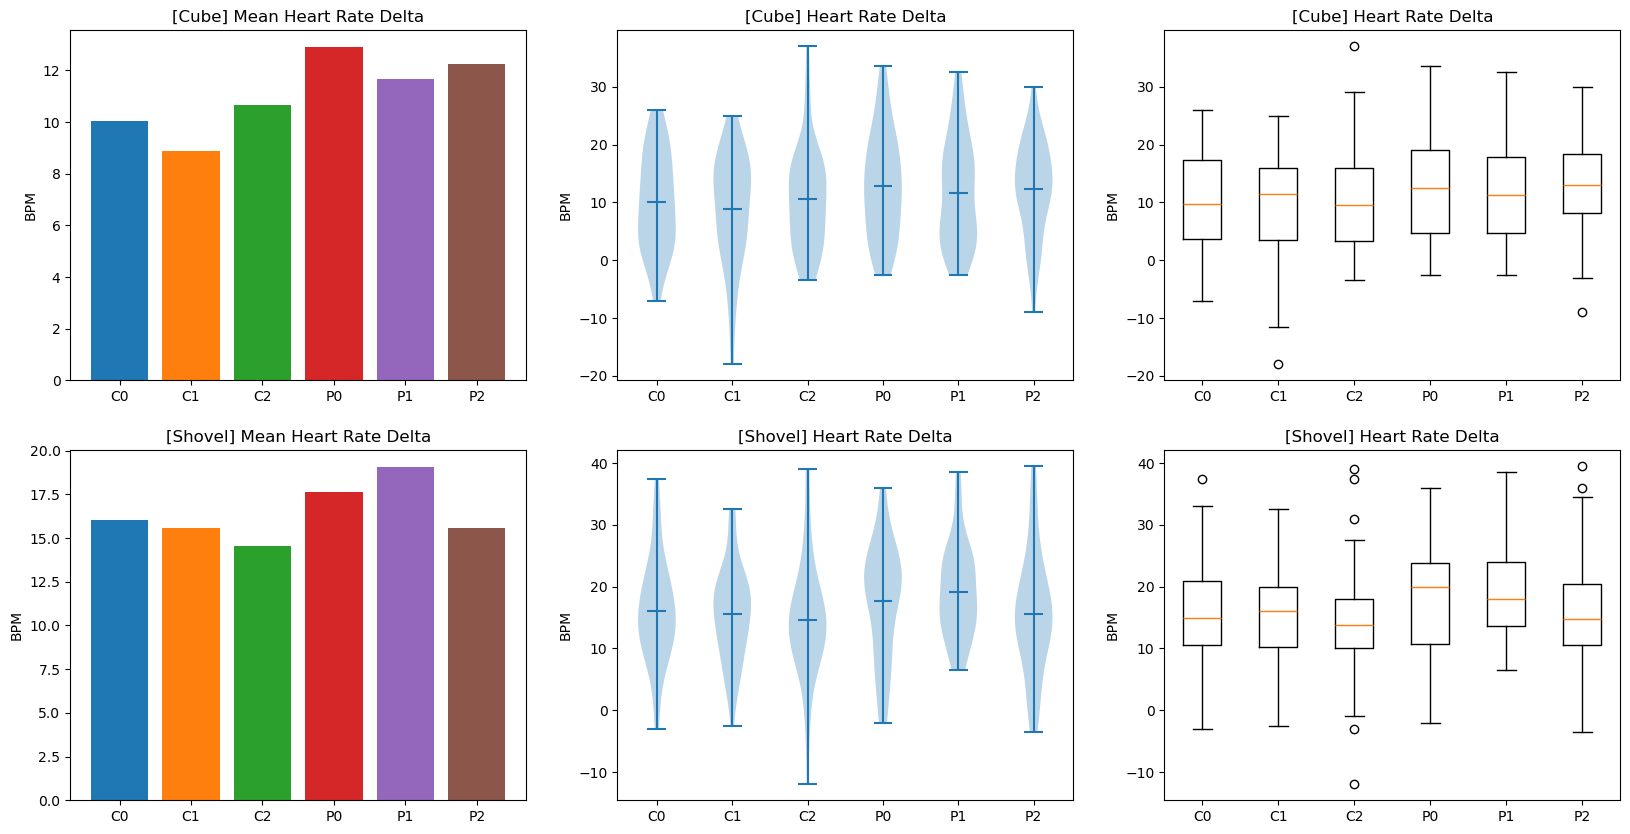

[Cube] Heart Rate Delta


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),367.937500,1.0,4.665652,0.031738,✅
C(Scaling),78.579365,2.0,0.498215,0.608226,❌
C(Device):C(Scaling),20.738095,2.0,0.131485,0.876854,❌
Residual,19399.779762,246.0,NaN,NaN,❌


[Shovel] Heart Rate Delta


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),264.142857,1.0,3.408876,0.066048,❌
C(Scaling),237.597222,2.0,1.533147,0.217911,❌
C(Device):C(Scaling),70.827381,2.0,0.457029,0.633699,❌
Residual,19061.750000,246.0,NaN,NaN,❌


In [53]:
def hr_delta(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: pre_post_delta(x, hr_key), participants))
    return single_values

cube_values = list(map(lambda x: hr_delta(data, cube, x), conditions))
shovel_values = list(map(lambda x: hr_delta(data, shovel, x), conditions))

title = 'Heart Rate Delta'
ylabel = 'BPM'
plot_experiments(cube_values, shovel_values, title,ylabel)
two_way_anova(cube_values, cube, title)
two_way_anova(shovel_values, shovel, title)

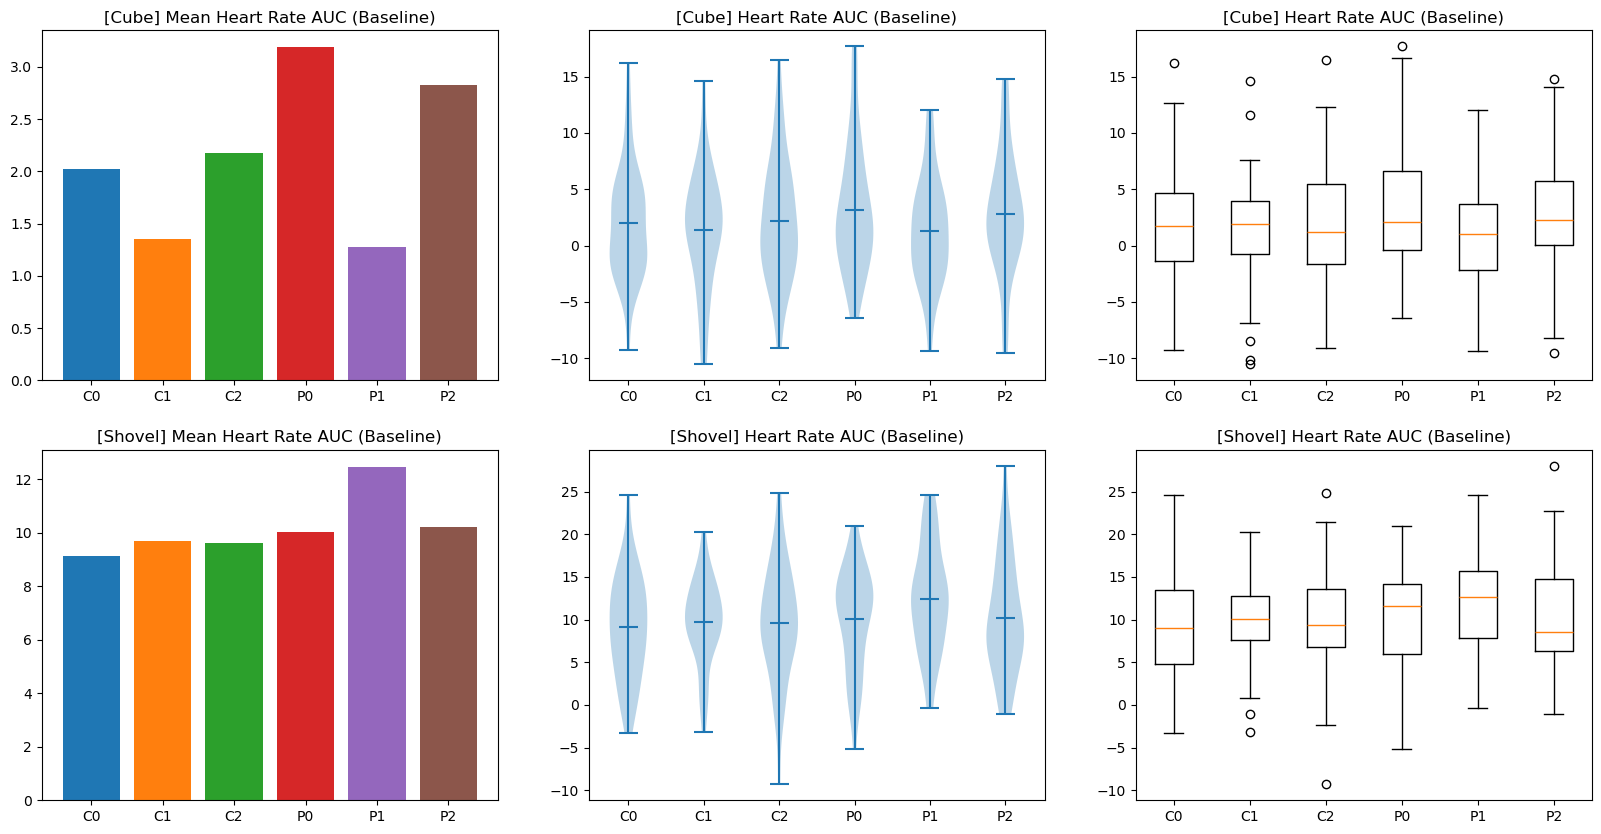

[Cube] Heart Rate AUC (Baseline)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),21.056273,1.0,0.767424,0.381870,❌
C(Scaling),86.930389,2.0,1.584147,0.207208,❌
C(Device):C(Scaling),16.457329,2.0,0.299905,0.741159,❌
Residual,6749.650310,246.0,NaN,NaN,❌


[Shovel] Heart Rate AUC (Baseline)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),125.977754,1.0,3.318582,0.069715,❌
C(Scaling),104.278238,2.0,1.373480,0.255159,❌
C(Device):C(Scaling),57.395290,2.0,0.755971,0.470642,❌
Residual,9338.484685,246.0,NaN,NaN,❌


In [54]:
def hr_auc_baseline(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: normalized_auc(x, hr_key, subtract_baseline=True), participants))
    return single_values

cube_values = list(map(lambda x: hr_auc_baseline(data, cube, x), conditions))
shovel_values = list(map(lambda x: hr_auc_baseline(data, shovel, x), conditions))

title = 'Heart Rate AUC (Baseline)'
ylabel = ''
plot_experiments(cube_values, shovel_values, title,ylabel)
two_way_anova(cube_values, cube, title)
two_way_anova(shovel_values, shovel, title)

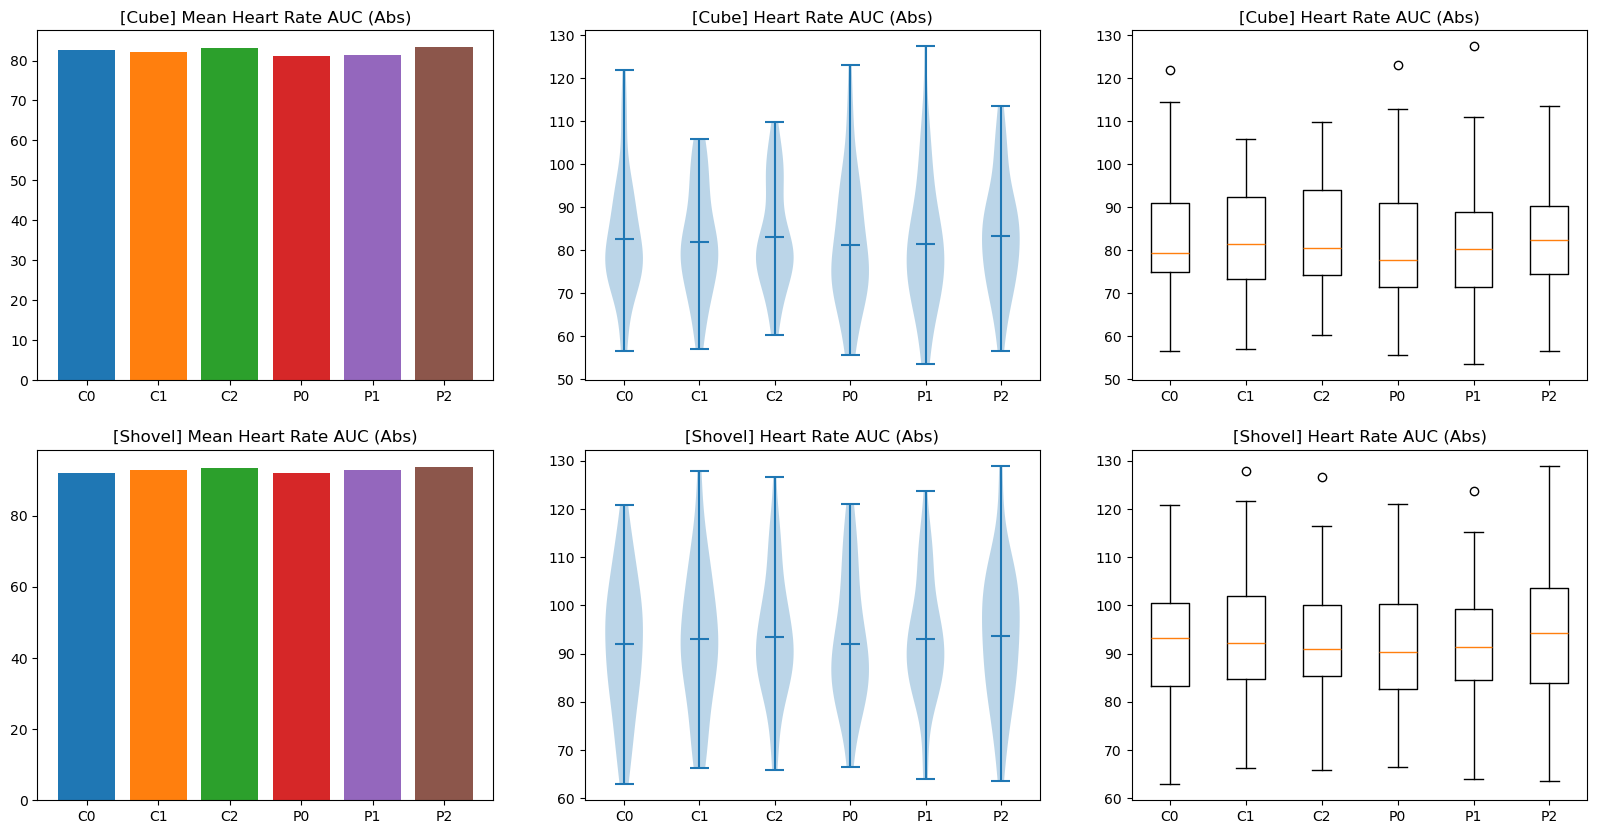

[Cube] Heart Rate AUC (Abs)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),25.646150,1.0,0.132599,0.716065,❌
C(Scaling),120.876697,2.0,0.312486,0.731916,❌
C(Device):C(Scaling),30.375726,2.0,0.078526,0.924501,❌
Residual,47579.162970,246.0,NaN,NaN,❌


[Shovel] Heart Rate AUC (Abs)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),0.162429,1.0,0.000859,0.976648,❌
C(Scaling),108.058620,2.0,0.285601,0.751811,❌
C(Device):C(Scaling),0.789583,2.0,0.002087,0.997915,❌
Residual,46537.720191,246.0,NaN,NaN,❌


In [55]:
def hr_auc(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: normalized_auc(x, hr_key), participants))
    return single_values

cube_values = list(map(lambda x: hr_auc(data, cube, x), conditions))
shovel_values = list(map(lambda x: hr_auc(data, shovel, x), conditions))

title = 'Heart Rate AUC (Abs)'
ylabel = ''
plot_experiments(cube_values, shovel_values, title,ylabel)
two_way_anova(cube_values, cube, title)
two_way_anova(shovel_values, shovel, title)

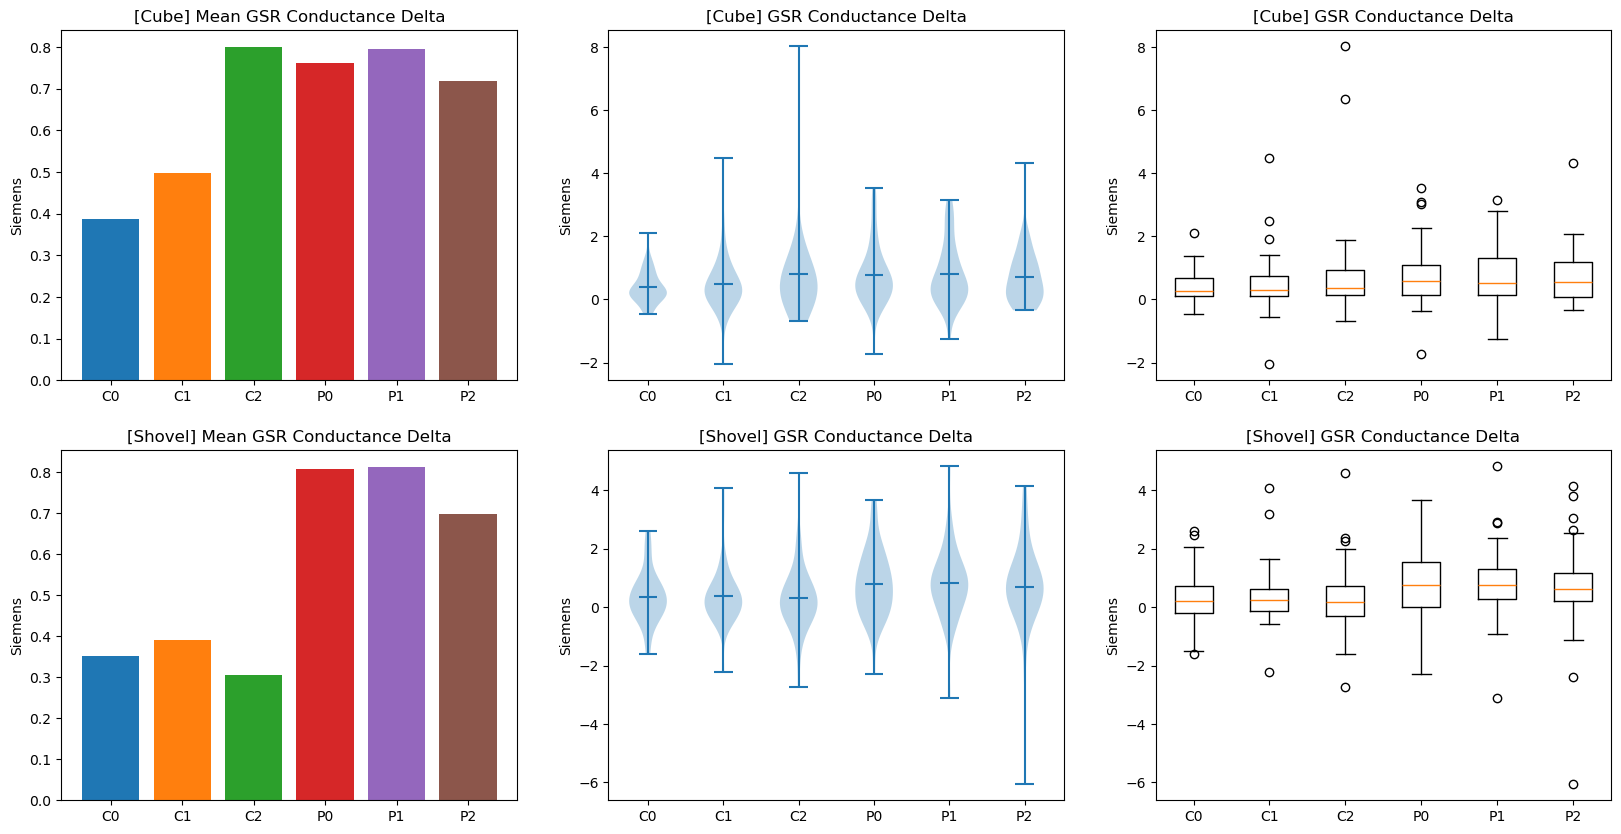

[Cube] GSR Conductance Delta


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),2.426022,1.0,2.298039,0.130821,❌
C(Scaling),1.446899,2.0,0.685284,0.504906,❌
C(Device):C(Scaling),2.512001,2.0,1.189741,0.306045,❌
Residual,259.700272,246.0,NaN,NaN,❌


[Shovel] GSR Conductance Delta


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),11.297391,1.0,7.819251,0.005578,✅
C(Scaling),0.466410,2.0,0.161408,0.851035,❌
C(Device):C(Scaling),0.045411,2.0,0.015715,0.984409,❌
Residual,355.425120,246.0,NaN,NaN,❌


In [56]:
def gsr_con_delta(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: pre_post_delta(x, gsr_con_key), participants))
    return single_values

cube_values = list(map(lambda x: gsr_con_delta(data, cube, x), conditions))
shovel_values = list(map(lambda x: gsr_con_delta(data, shovel, x), conditions))

title = 'GSR Conductance Delta'
ylabel = 'Siemens'
plot_experiments(cube_values, shovel_values, title,ylabel)
two_way_anova(cube_values, cube, title)
two_way_anova(shovel_values, shovel, title)

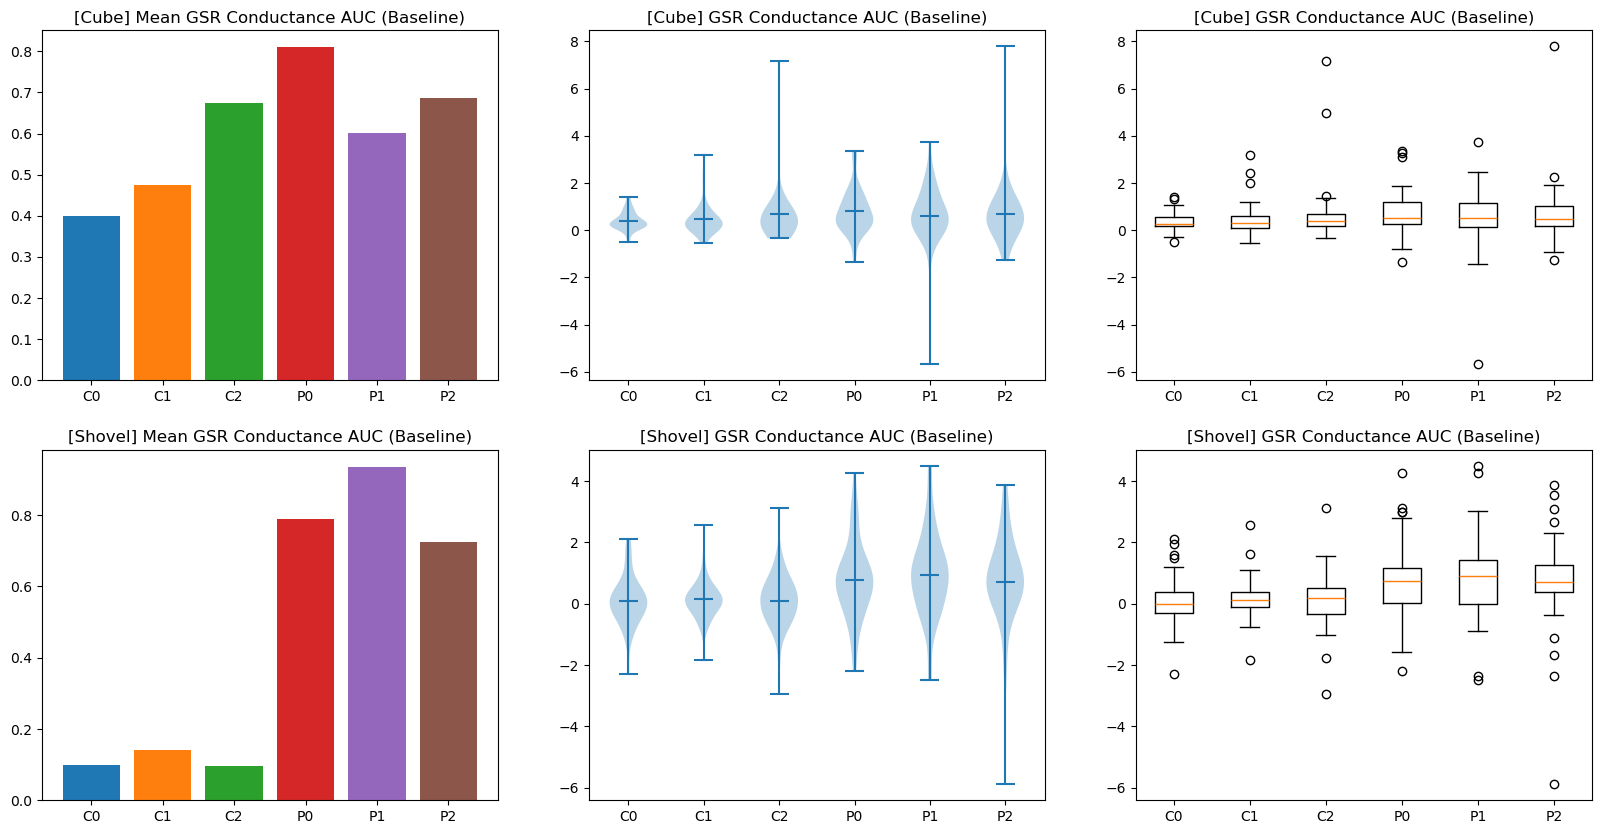

[Cube] GSR Conductance AUC (Baseline)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),2.118443,1.0,1.857419,0.174169,❌
C(Scaling),0.846154,2.0,0.370948,0.690465,❌
C(Device):C(Scaling),1.780156,2.0,0.780407,0.459351,❌
Residual,280.570483,246.0,NaN,NaN,❌


[Shovel] GSR Conductance AUC (Baseline)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),31.205524,1.0,22.860180,0.000003,✅
C(Scaling),0.724213,2.0,0.265268,0.767220,❌
C(Device):C(Scaling),0.300877,2.0,0.110207,0.895693,❌
Residual,335.804843,246.0,NaN,NaN,❌


In [57]:
def gsr_con_auc_baseline(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: normalized_auc(x, gsr_con_key, subtract_baseline=True), participants))
    return single_values

cube_values = list(map(lambda x: gsr_con_auc_baseline(data, cube, x), conditions))
shovel_values = list(map(lambda x: gsr_con_auc_baseline(data, shovel, x), conditions))

title = 'GSR Conductance AUC (Baseline)'
ylabel = ''
plot_experiments(cube_values, shovel_values, title,ylabel)
two_way_anova(cube_values, cube, title)
two_way_anova(shovel_values, shovel, title)

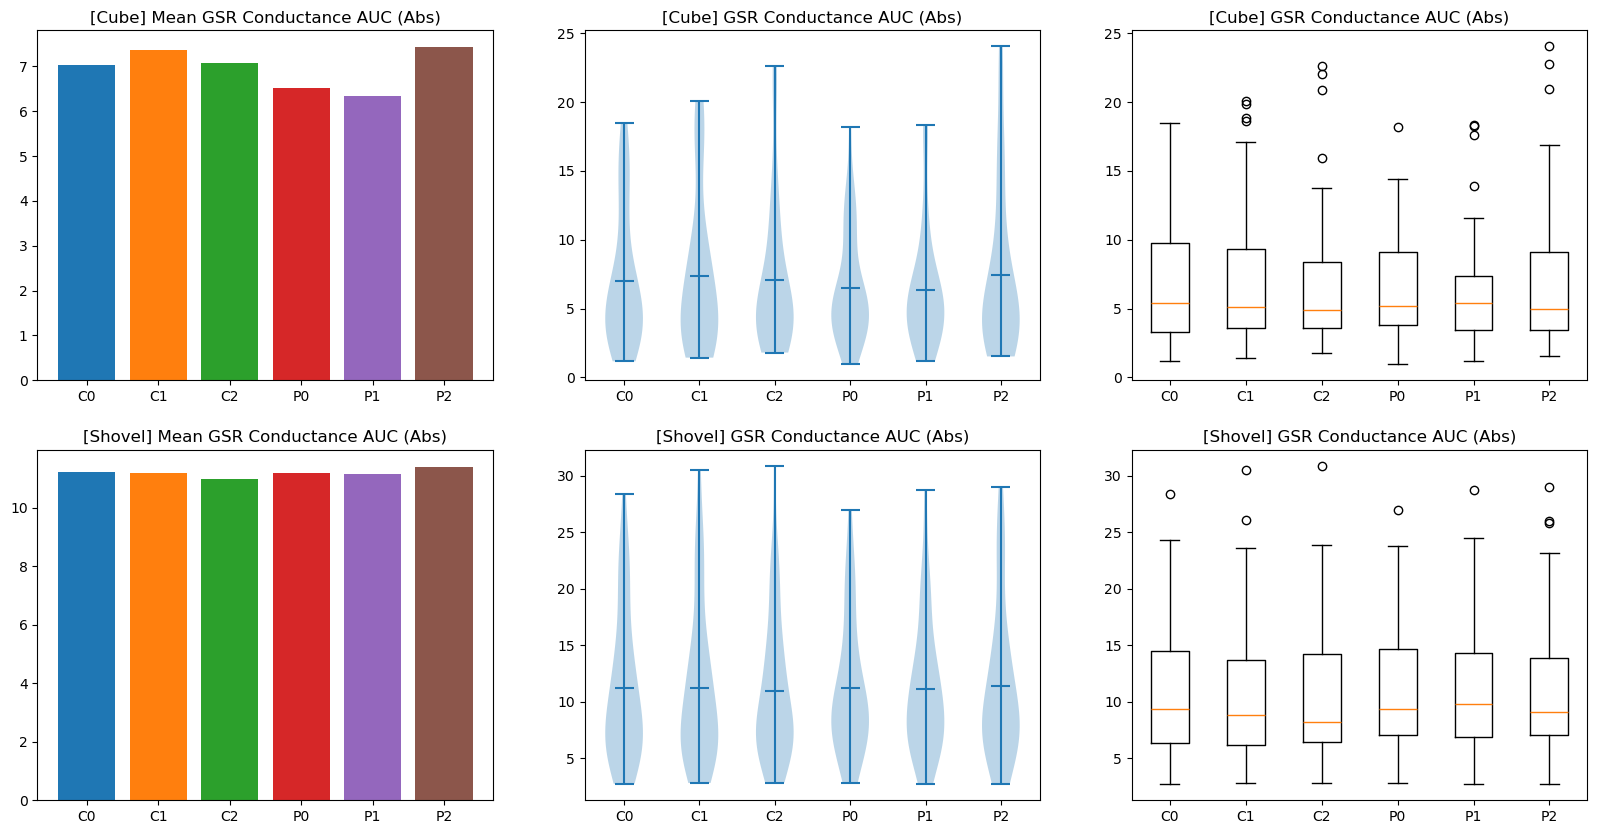

[Cube] GSR Conductance AUC (Abs)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),9.765031,1.0,0.378608,0.538918,❌
C(Scaling),11.354241,2.0,0.220112,0.802587,❌
C(Device):C(Scaling),19.842592,2.0,0.384667,0.681086,❌
Residual,6344.816065,246.0,NaN,NaN,❌


[Shovel] GSR Conductance AUC (Abs)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),0.750652,1.0,0.018352,0.892350,❌
C(Scaling),0.087682,2.0,0.001072,0.998929,❌
C(Device):C(Scaling),2.753056,2.0,0.033654,0.966910,❌
Residual,10061.961554,246.0,NaN,NaN,❌


In [58]:
def gsr_con_auc(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: normalized_auc(x, gsr_con_key), participants))
    return single_values

cube_values = list(map(lambda x: gsr_con_auc(data, cube, x), conditions))
shovel_values = list(map(lambda x: gsr_con_auc(data, shovel, x), conditions))

title = 'GSR Conductance AUC (Abs)'
ylabel = ''
plot_experiments(cube_values, shovel_values, title,ylabel)
two_way_anova(cube_values, cube, title)
two_way_anova(shovel_values, shovel, title)

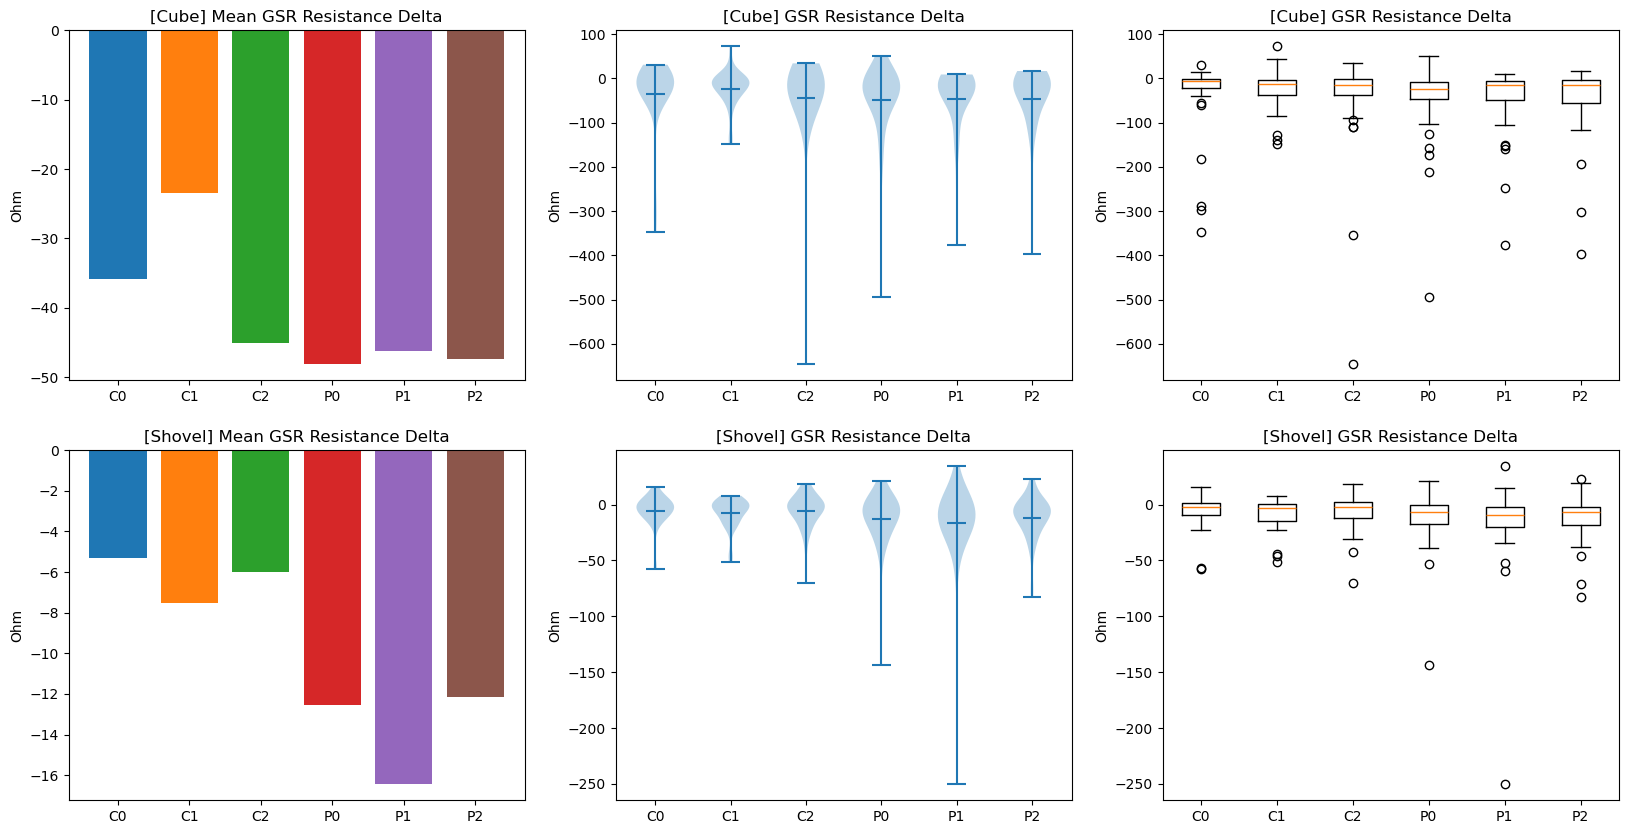

[Cube] GSR Resistance Delta


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),9.748017e+03,1.0,1.402666,0.237421,❌
C(Scaling),5.592504e+03,2.0,0.402359,0.669180,❌
C(Device):C(Scaling),4.460845e+03,2.0,0.320941,0.725769,❌
Residual,1.709611e+06,246.0,NaN,NaN,❌


[Shovel] GSR Resistance Delta


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),3471.162033,1.0,6.191543,0.013499,✅
C(Scaling),498.793768,2.0,0.444851,0.641434,❌
C(Device):C(Scaling),78.850866,2.0,0.070324,0.932111,❌
Residual,137914.871725,246.0,NaN,NaN,❌


In [59]:
def gsr_res_delta(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: pre_post_delta(x, gsr_res_key), participants))
    return single_values

cube_values = list(map(lambda x: gsr_res_delta(data, cube, x), conditions))
shovel_values = list(map(lambda x: gsr_res_delta(data, shovel, x), conditions))

title = 'GSR Resistance Delta'
ylabel = 'Ohm'
plot_experiments(cube_values, shovel_values, title,ylabel)
two_way_anova(cube_values, cube, title)
two_way_anova(shovel_values, shovel, title)

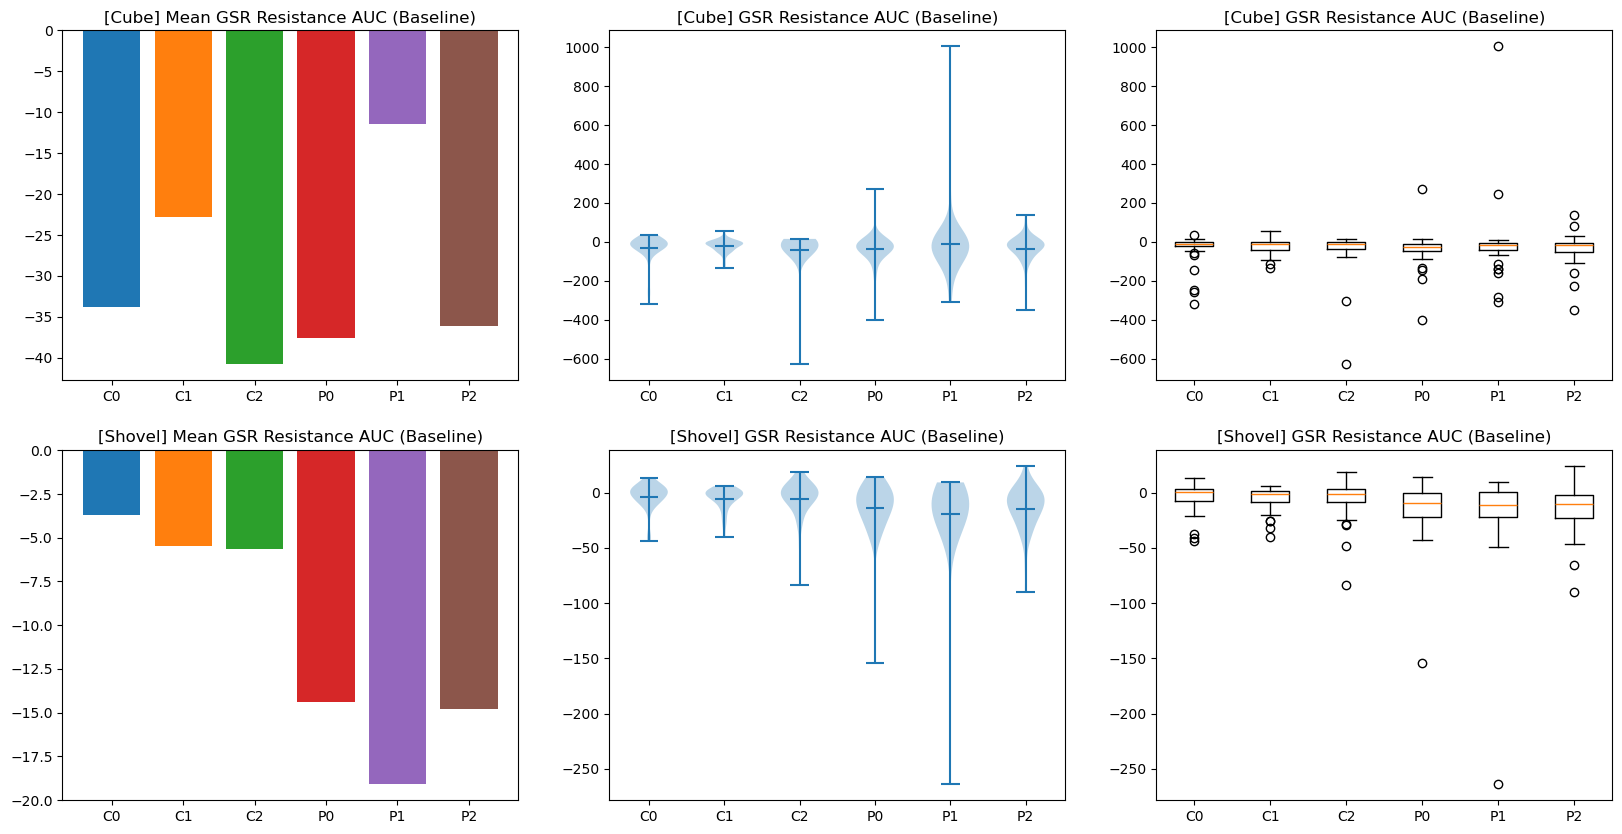

[Cube] GSR Resistance AUC (Baseline)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),1.061948e+03,1.0,0.100175,0.751889,❌
C(Scaling),2.252876e+04,2.0,1.062580,0.347144,❌
C(Device):C(Scaling),2.439667e+03,2.0,0.115068,0.891353,❌
Residual,2.607838e+06,246.0,NaN,NaN,❌


[Shovel] GSR Resistance AUC (Baseline)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),7783.760988,1.0,13.597895,0.000279,✅
C(Scaling),449.864822,2.0,0.392947,0.675487,❌
C(Device):C(Scaling),214.467751,2.0,0.187333,0.829286,❌
Residual,140816.295683,246.0,NaN,NaN,❌


In [60]:
def gsr_res_auc_baseline(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: normalized_auc(x, gsr_res_key, subtract_baseline=True), participants))
    return single_values

cube_values = list(map(lambda x: gsr_res_auc_baseline(data, cube, x), conditions))
shovel_values = list(map(lambda x: gsr_res_auc_baseline(data, shovel, x), conditions))

title = 'GSR Resistance AUC (Baseline)'
ylabel = ''
plot_experiments(cube_values, shovel_values, title,ylabel)
two_way_anova(cube_values, cube, title)
two_way_anova(shovel_values, shovel, title)

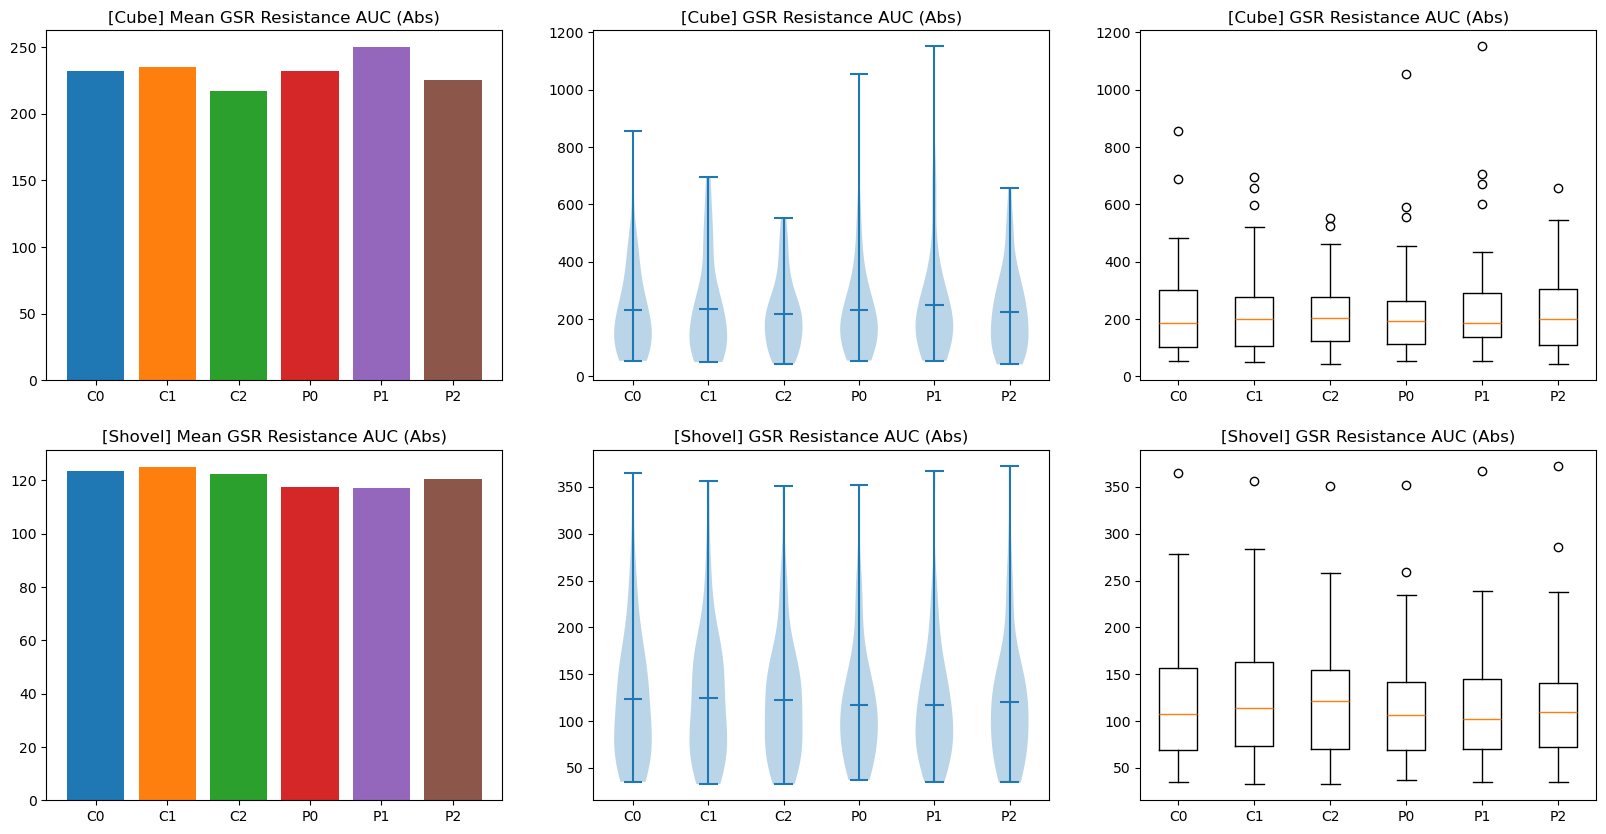

[Cube] GSR Resistance AUC (Abs)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),3.829179e+03,1.0,0.129582,0.719174,❌
C(Scaling),1.931593e+04,2.0,0.326833,0.721517,❌
C(Device):C(Scaling),2.175154e+03,2.0,0.036804,0.963870,❌
Residual,7.269338e+06,246.0,NaN,NaN,❌


[Shovel] GSR Resistance AUC (Abs)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),1.844904e+03,1.0,0.386682,0.534624,❌
C(Scaling),4.018598e+01,2.0,0.004211,0.995798,❌
C(Device):C(Scaling),3.750174e+02,2.0,0.039301,0.961467,❌
Residual,1.173693e+06,246.0,NaN,NaN,❌


In [61]:
def gsr_res_auc(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: normalized_auc(x, gsr_res_key), participants))
    return single_values

cube_values = list(map(lambda x: gsr_res_auc(data, cube, x), conditions))
shovel_values = list(map(lambda x: gsr_res_auc(data, shovel, x), conditions))

title = 'GSR Resistance AUC (Abs)'
ylabel = ''
plot_experiments(cube_values, shovel_values, title,ylabel)
two_way_anova(cube_values, cube, title)
two_way_anova(shovel_values, shovel, title)

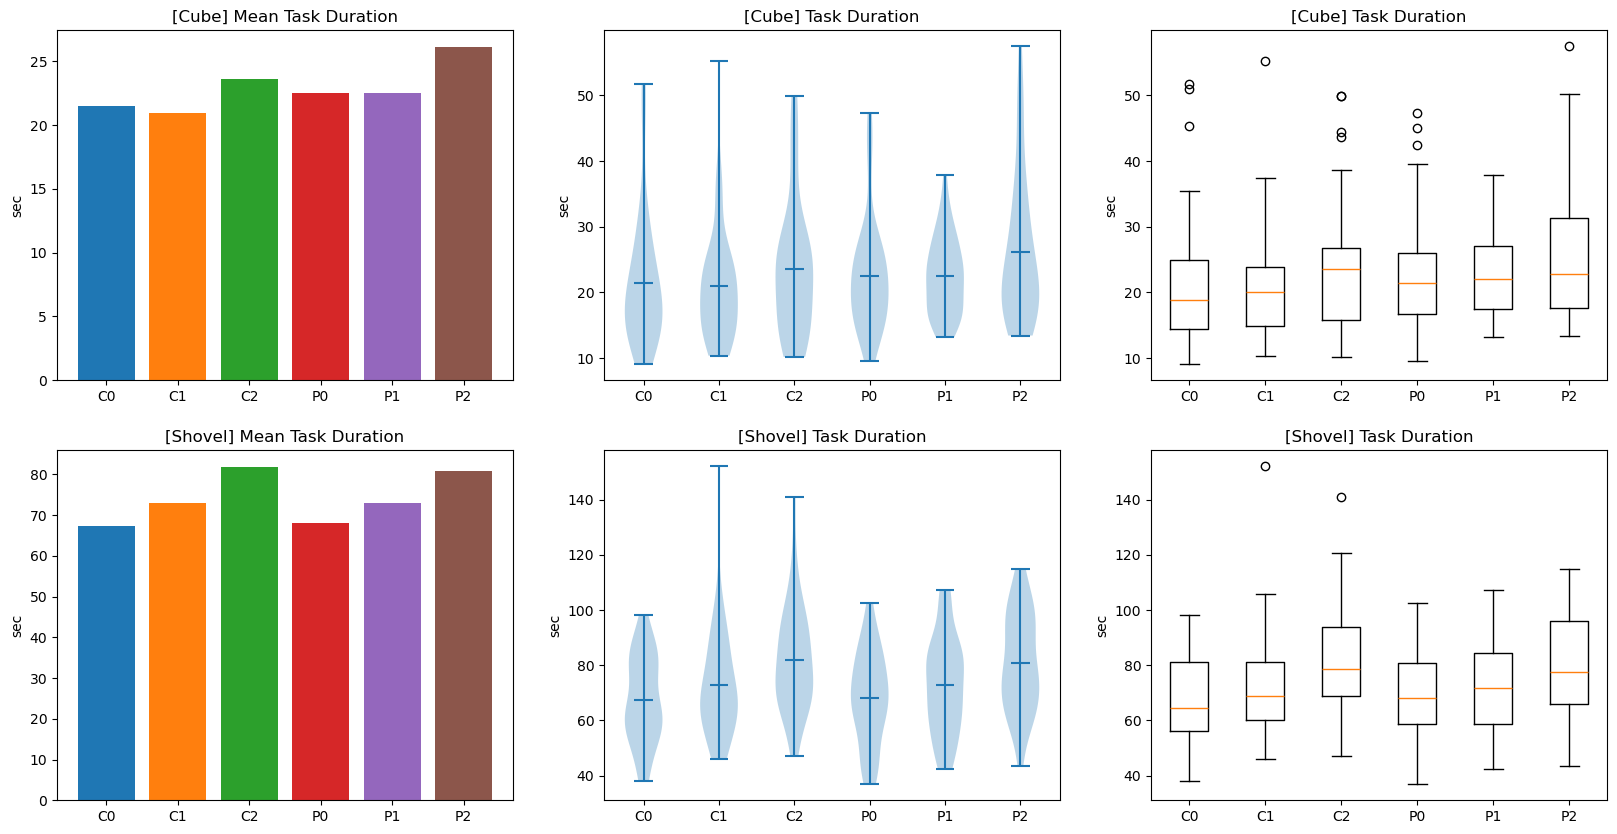

[Cube] Task Duration


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),182.927808,1.0,2.147877,0.144044,❌
C(Scaling),509.542389,2.0,2.991437,0.052045,❌
C(Device):C(Scaling),22.108316,2.0,0.129794,0.878336,❌
Residual,20951.036604,246.0,NaN,NaN,❌


[Shovel] Task Duration


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),0.061664,1.0,0.000196,0.988855,❌
C(Scaling),7891.795976,2.0,12.510281,0.000007,✅
C(Device):C(Scaling),34.111426,2.0,0.054074,0.947373,❌
Residual,77591.455486,246.0,NaN,NaN,❌


In [81]:
def single_duration(p):
    return (p[end_ts] - p[start_ts]) / 1_000

def agg_duration(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(single_duration, participants))
    return single_values

cube_values = list(map(lambda x: agg_duration(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_duration(data, shovel, x), conditions))

title = 'Task Duration'
ylabel = 'sec'
plot_experiments(cube_values, shovel_values, title,ylabel)
two_way_anova(cube_values, cube, title)
two_way_anova(shovel_values, shovel, title)

In [63]:
def agg_curve(data, ax, e, c, key, ylim, ylabel):
    participants = list(map(lambda x: x[e][c], data))
    trimmmed_dfs = list(map(lambda x: trim_df(x[imot], min_ts = x[start_ts] - baseline_ms, max_ts = x[end_ts] + baseline_ms), participants))
    dfs = list(map(lambda x: x.dropna(subset = key).set_index(unified_delta_key, drop = False), trimmmed_dfs))

    dfs = list(map(lambda x: x[np.abs(stats.zscore(x[key])) < max_z_score], dfs))

    max_duration = 155 if e == shovel else 90

    ax.title.set_text(c + " [" + e + "] ")
    ax.set_xlim([-30,max_duration])
    ax.set_ylim(ylim)
    ax.set_xlabel('sec')
    ax.set_ylabel(ylabel)

    #Scatter
    # scatter_dfs = list(map(lambda x: x.dropna(subset = key), trimmmed_dfs))
    # all_values = pd.concat(scatter_dfs).sort_values(by=unified_delta_key)
    # x = list(map(lambda x: x / 1000, all_values[unified_delta_key]))
    # y = all_values[key]
    # alpha = 0.1
    # ax.scatter(x, y, alpha=alpha, color="tab:orange", s=5)

    sample_pts_ms = list(map(lambda x: x * 1000, range(-30, max_duration, 1)))
    synced_samples = []
    for i in sample_pts_ms:
        sample_values = []
        for df in dfs:
            iloc_idx = df.index.get_indexer([i], method='nearest')  # returns absolute index into df e.g. array([5])  
            nearest_row = df.iloc[iloc_idx[0]]
            nearest_ms = nearest_row[unified_delta_key]
            nearest_value = nearest_row[key]
            if abs(nearest_ms - i) < 1_000:
                sample_values.append(nearest_value)
            else:
                sample_values.append(np.nan)
        synced_samples.append(sample_values)

    #Individual
    x = list(map(lambda x: x / 1000, sample_pts_ms))
    for i in range(len(participants)):
        participant_values = list(map(lambda x: x[i], synced_samples))
        ax.plot(x, participant_values, color="tab:orange", alpha= 0.1, lw=3)

    #Trend
    min_agg_count = 6
    valid_samples = list(map(lambda x: list(filter(lambda y: not np.isnan(y), x)), synced_samples))
    agg_values = list(map(lambda x: [np.mean(x) if len(x) >= min_agg_count else np.nan, 1.96 * np.std(x) / np.sqrt(len(x))if len(x) >= min_agg_count else np.nan], valid_samples))
    y_mean = list(map(lambda x: x[0], agg_values))
    y_top = list(map(lambda x: x[0] + x[1] * 0.5, agg_values))
    y_bottom = list(map(lambda x: x[0] - x[1] * 0.5, agg_values))
    ax.plot(x, y_mean, color="tab:blue")
    ax.fill_between(x,y_bottom, y_top, color='tab:blue', alpha=0.3)

    #VLines
    durations = list(map(lambda x: (x[end_ts] - x[start_ts]) / 1_000, participants))
    min_end = np.min(durations)
    max_end = np.max(durations)
    end_quantiles = np.quantile(durations, q = np.arange(0.25, 1, 0.25))
    q_1 = end_quantiles[0]
    median = end_quantiles[1]
    q_3 = end_quantiles[2]
    ax.axvline(x=0, color='green', label='Start')
    ax.axvline(x=min_end, color='red', linestyle='--', alpha= 0.3)
    ax.axvline(x=median, color='red')
    ax.axvline(x=max_end, color='red', linestyle='--', alpha= 0.3)
    ymin, ymax = ax.get_ylim()
    rect = patches.Rectangle((q_1, ymin), q_3-q_1, ymax-ymin, facecolor='red')
    rect.set_alpha(0.3)
    ax.add_patch(rect)

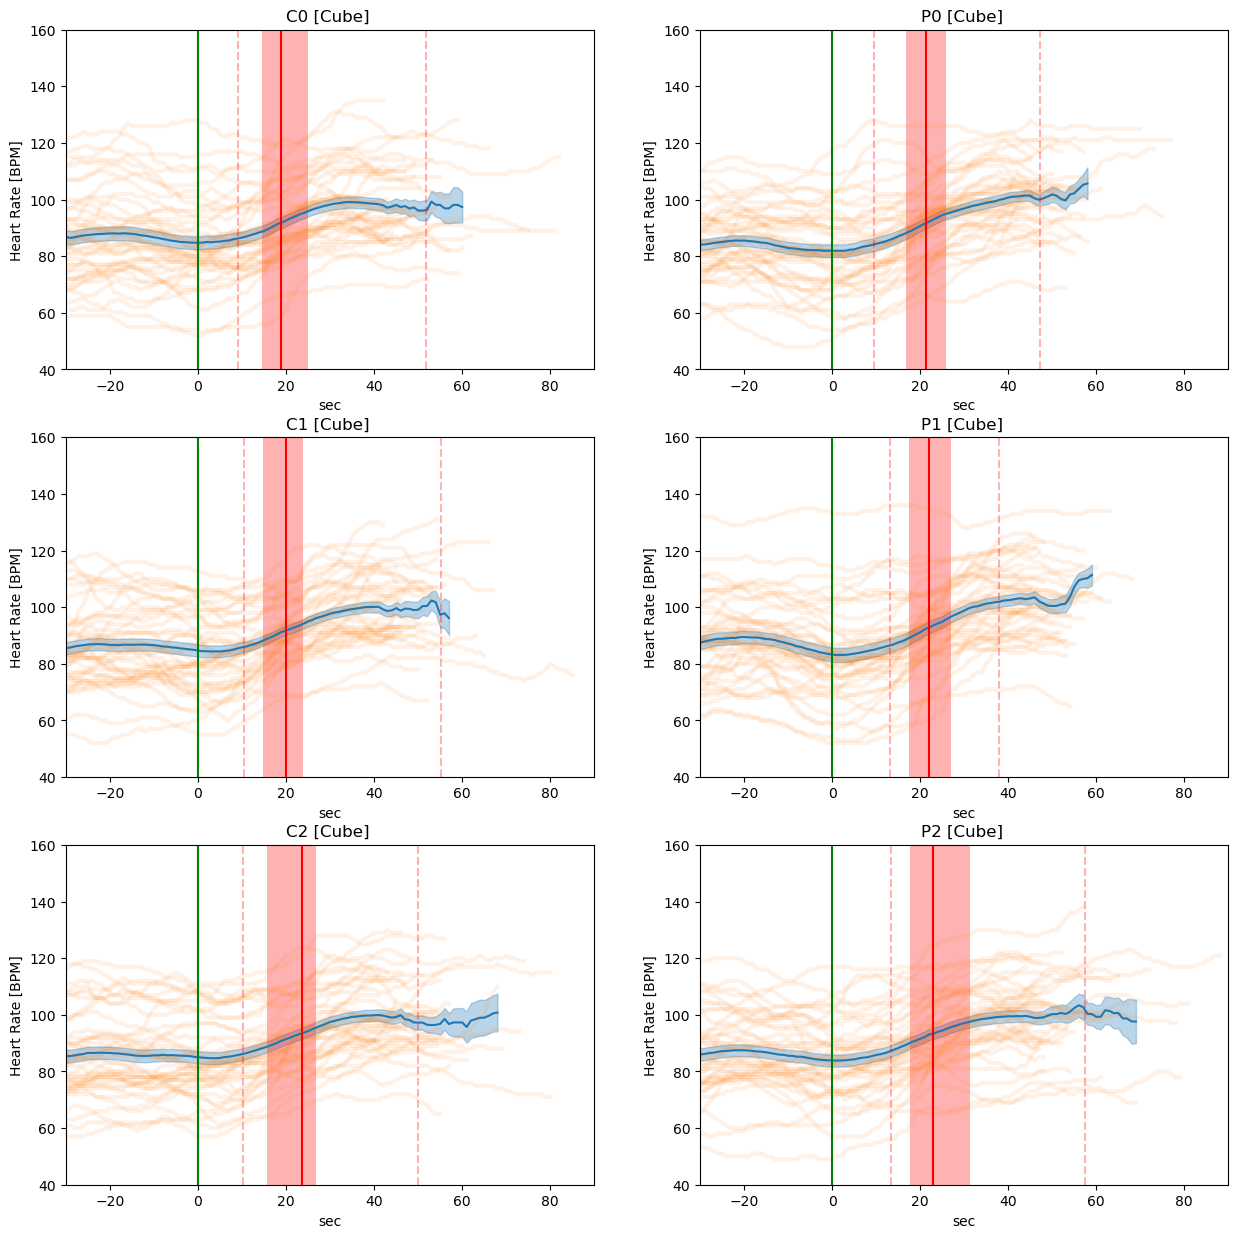

In [64]:
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
ylim = [40,160]
ylabel = 'Heart Rate [BPM]'

agg_curve(data, axs[0,0], cube, c_0, hr_key, ylim, ylabel)
agg_curve(data, axs[1,0], cube, c_1, hr_key, ylim, ylabel)
agg_curve(data, axs[2,0], cube, c_2, hr_key, ylim, ylabel)
agg_curve(data, axs[0,1], cube, p_0, hr_key, ylim, ylabel)
agg_curve(data, axs[1,1], cube, p_1, hr_key, ylim, ylabel)
agg_curve(data, axs[2,1], cube, p_2, hr_key, ylim, ylabel)

plt.show()

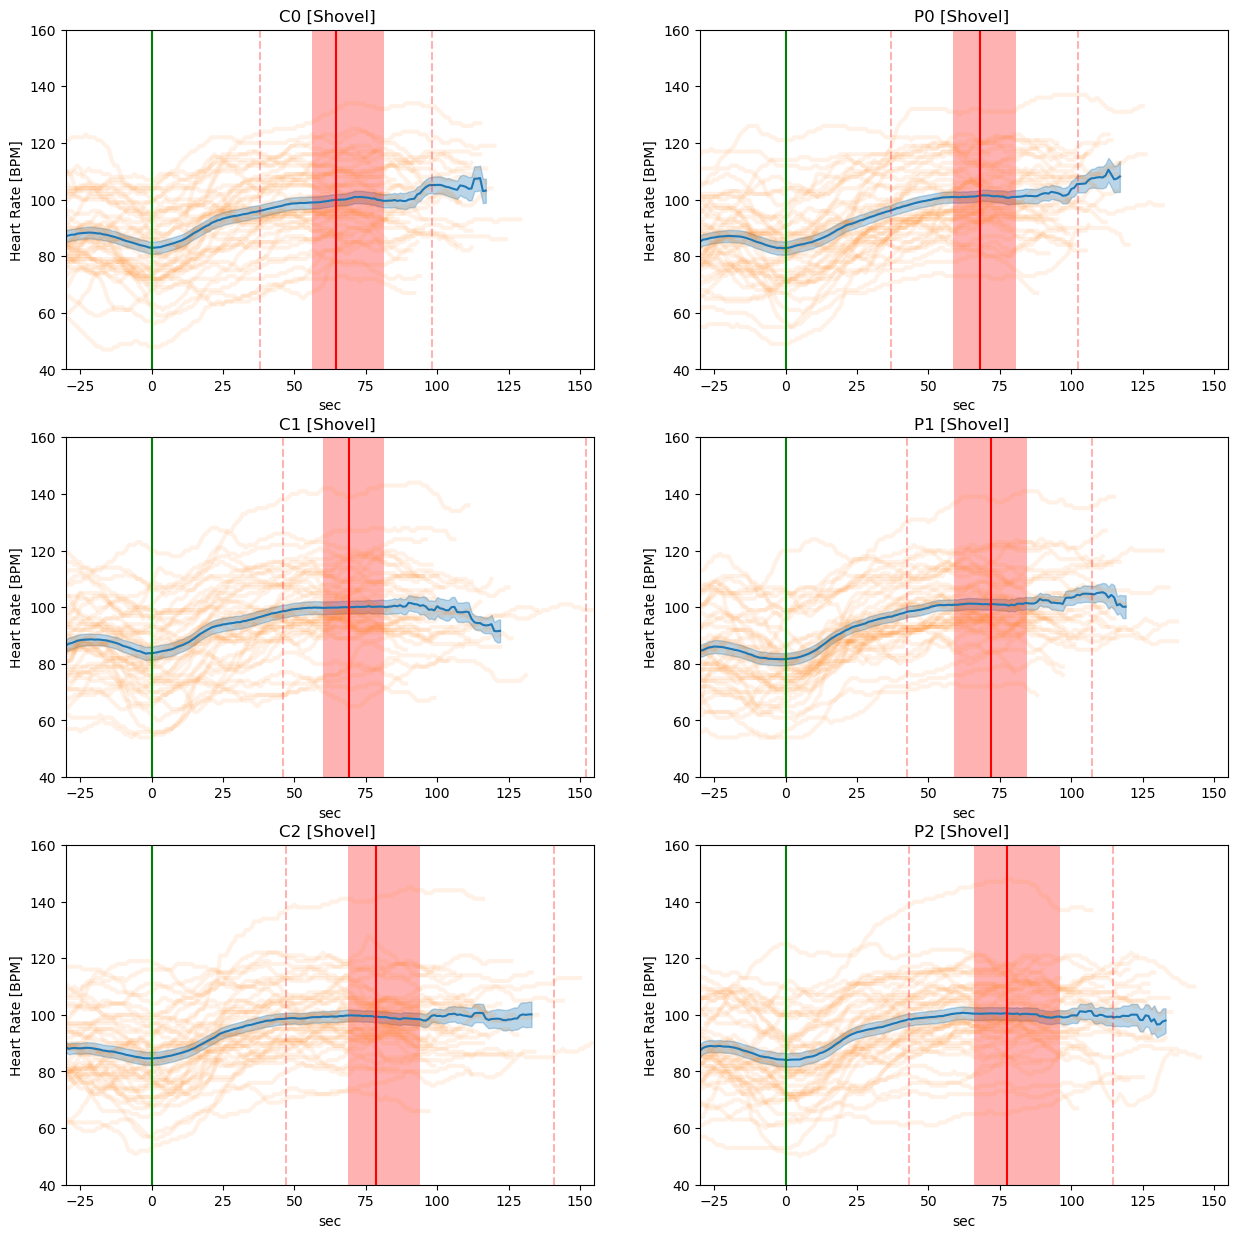

In [65]:
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
ylim = [40,160]
ylabel = 'Heart Rate [BPM]'

agg_curve(data, axs[0,0], shovel, c_0, hr_key, ylim, ylabel)
agg_curve(data, axs[1,0], shovel, c_1, hr_key, ylim, ylabel)
agg_curve(data, axs[2,0], shovel, c_2, hr_key, ylim, ylabel)
agg_curve(data, axs[0,1], shovel, p_0, hr_key, ylim, ylabel)
agg_curve(data, axs[1,1], shovel, p_1, hr_key, ylim, ylabel)
agg_curve(data, axs[2,1], shovel, p_2, hr_key, ylim, ylabel)

plt.show()

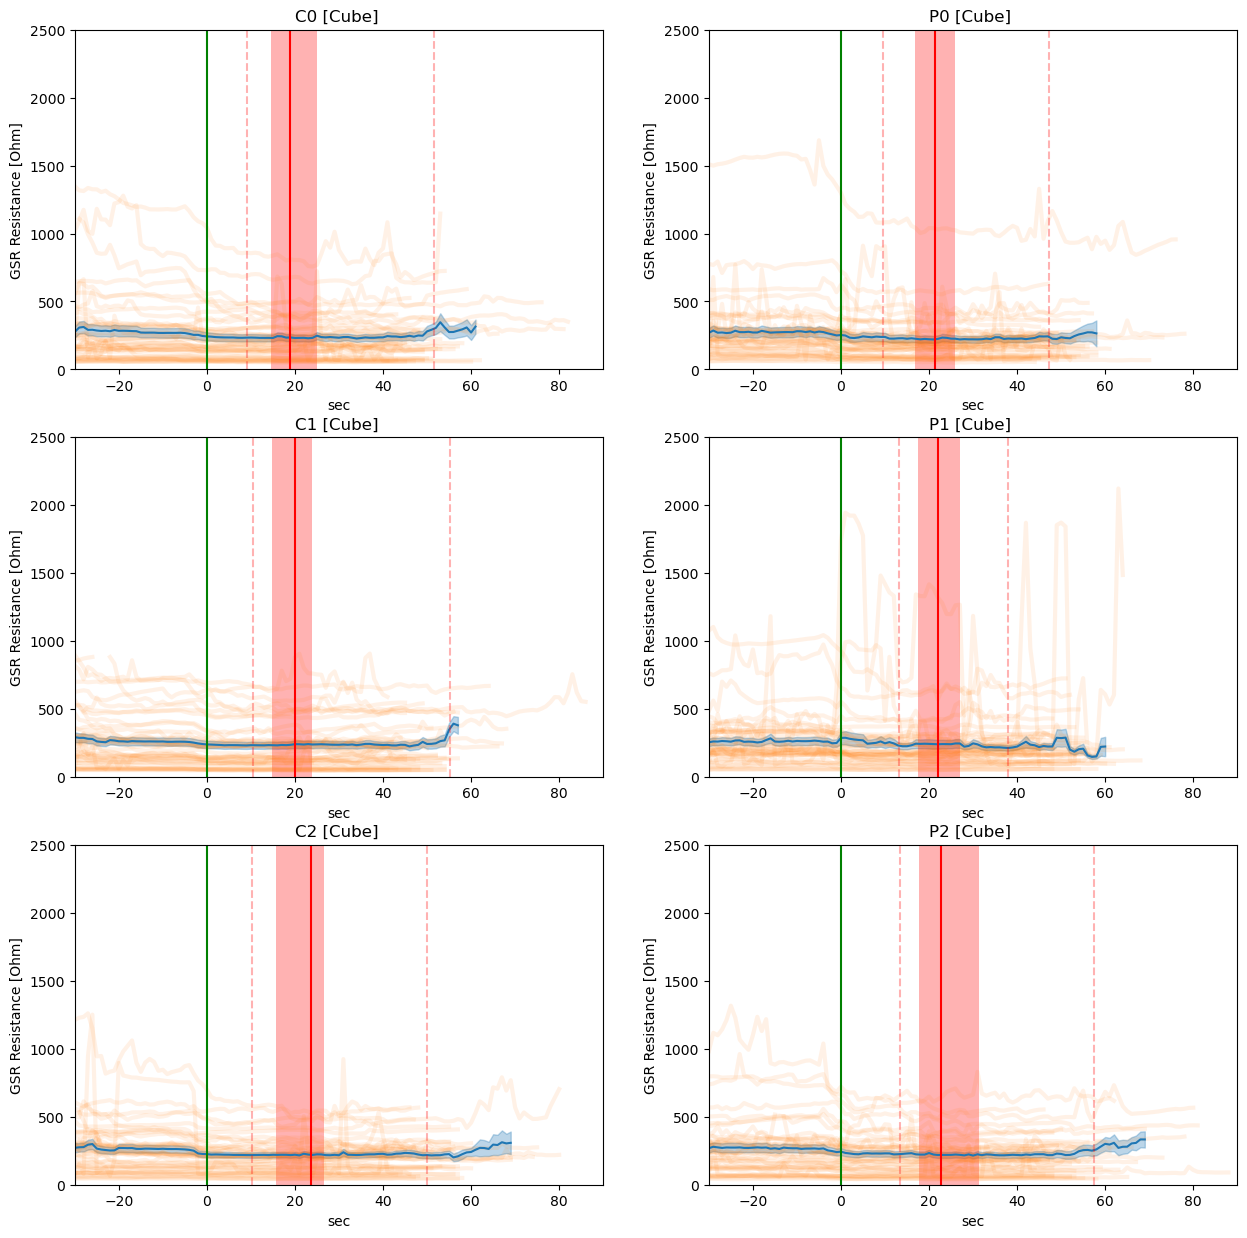

In [66]:
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
ylim = [0,2500]
ylabel = 'GSR Resistance [Ohm]'

agg_curve(data, axs[0,0], cube, c_0, gsr_res_key, ylim, ylabel)
agg_curve(data, axs[1,0], cube, c_1, gsr_res_key, ylim, ylabel)
agg_curve(data, axs[2,0], cube, c_2, gsr_res_key, ylim, ylabel)
agg_curve(data, axs[0,1], cube, p_0, gsr_res_key, ylim, ylabel)
agg_curve(data, axs[1,1], cube, p_1, gsr_res_key, ylim, ylabel)
agg_curve(data, axs[2,1], cube, p_2, gsr_res_key, ylim, ylabel)

plt.show()

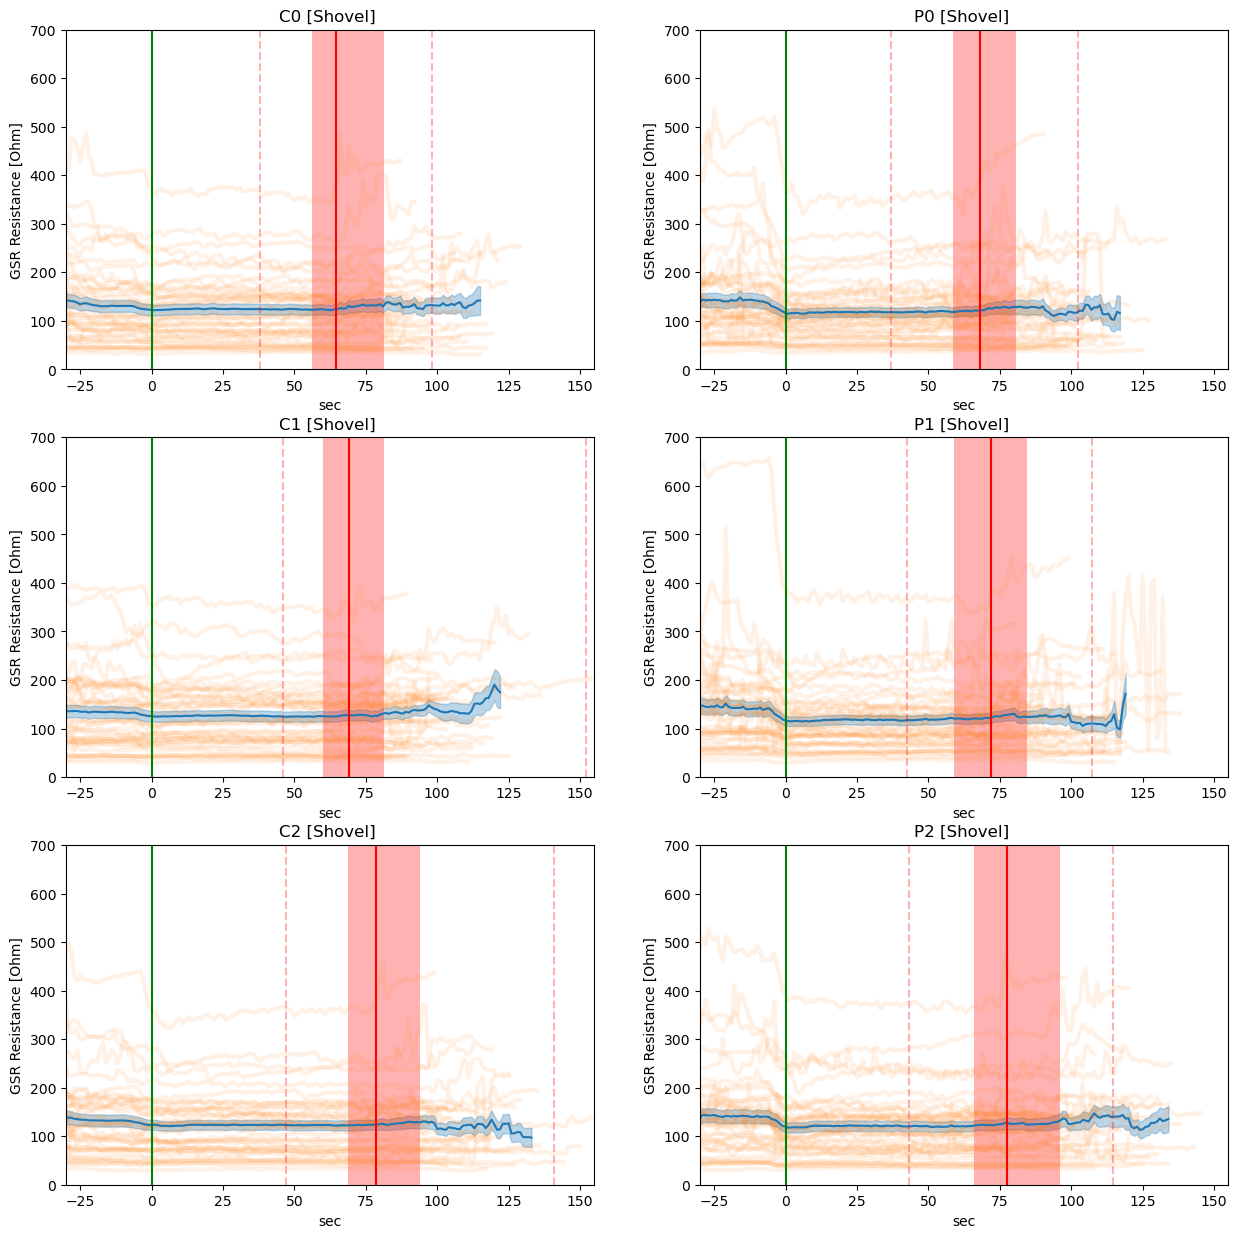

In [67]:
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
ylim = [0,700]
ylabel = 'GSR Resistance [Ohm]'

agg_curve(data, axs[0,0], shovel, c_0, gsr_res_key, ylim, ylabel)
agg_curve(data, axs[1,0], shovel, c_1, gsr_res_key, ylim, ylabel)
agg_curve(data, axs[2,0], shovel, c_2, gsr_res_key, ylim, ylabel)
agg_curve(data, axs[0,1], shovel, p_0, gsr_res_key, ylim, ylabel)
agg_curve(data, axs[1,1], shovel, p_1, gsr_res_key, ylim, ylabel)
agg_curve(data, axs[2,1], shovel, p_2, gsr_res_key, ylim, ylabel)

plt.show()

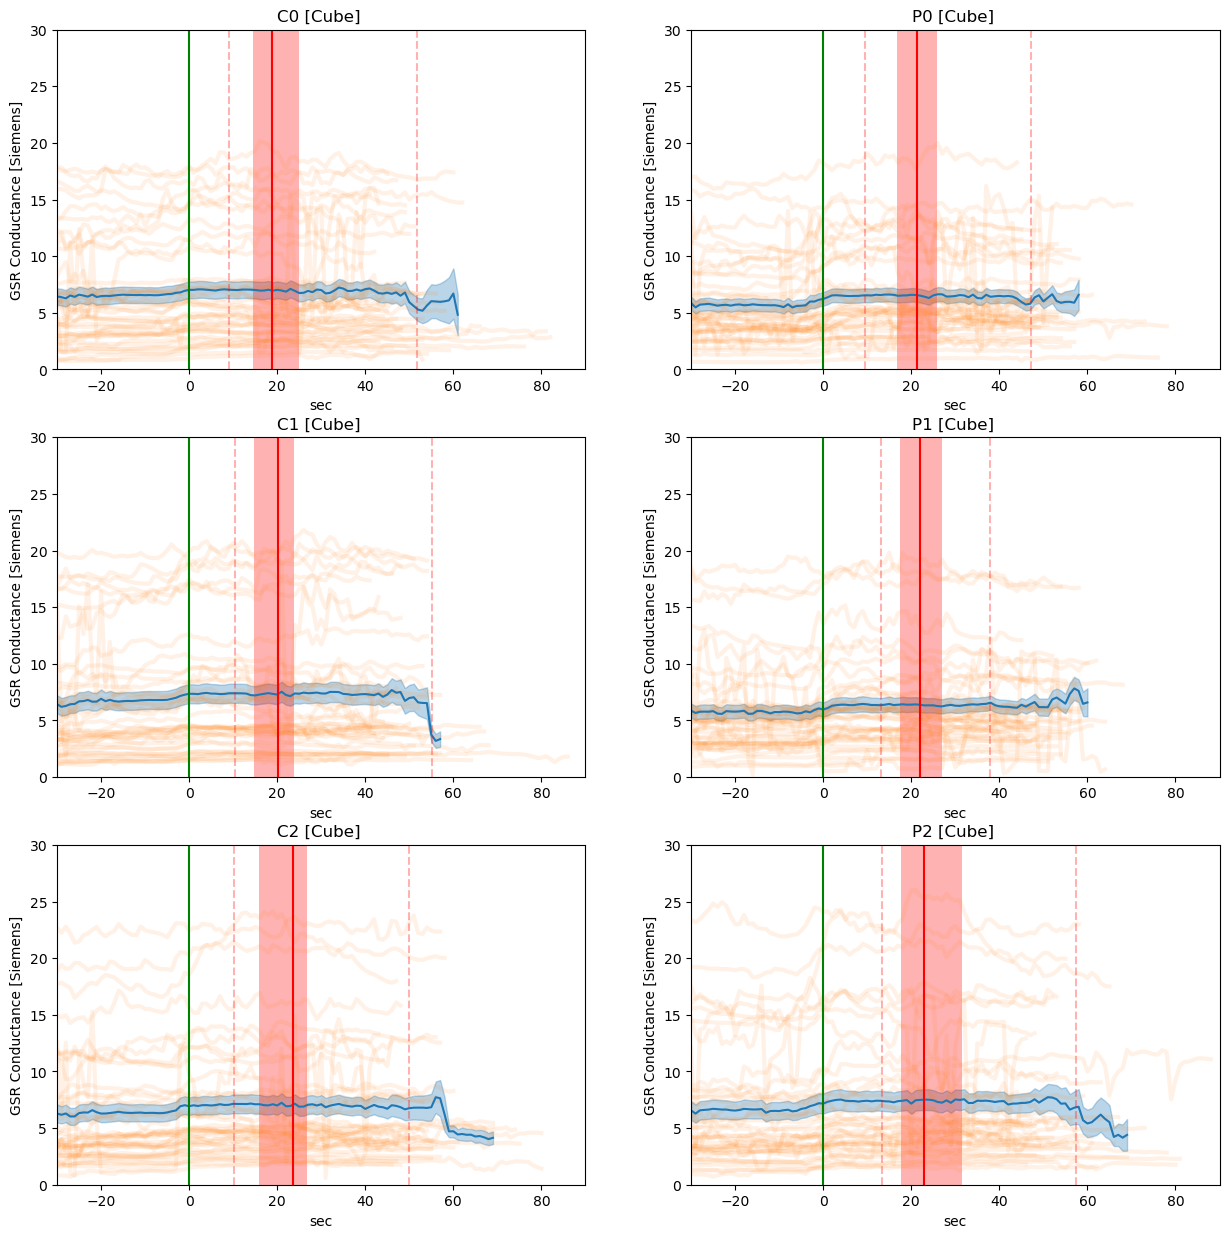

In [68]:
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
ylim = [0,30]
ylabel = 'GSR Conductance [Siemens]'

agg_curve(data, axs[0,0], cube, c_0, gsr_con_key, ylim, ylabel)
agg_curve(data, axs[1,0], cube, c_1, gsr_con_key, ylim, ylabel)
agg_curve(data, axs[2,0], cube, c_2, gsr_con_key, ylim, ylabel)
agg_curve(data, axs[0,1], cube, p_0, gsr_con_key, ylim, ylabel)
agg_curve(data, axs[1,1], cube, p_1, gsr_con_key, ylim, ylabel)
agg_curve(data, axs[2,1], cube, p_2, gsr_con_key, ylim, ylabel)

plt.show()

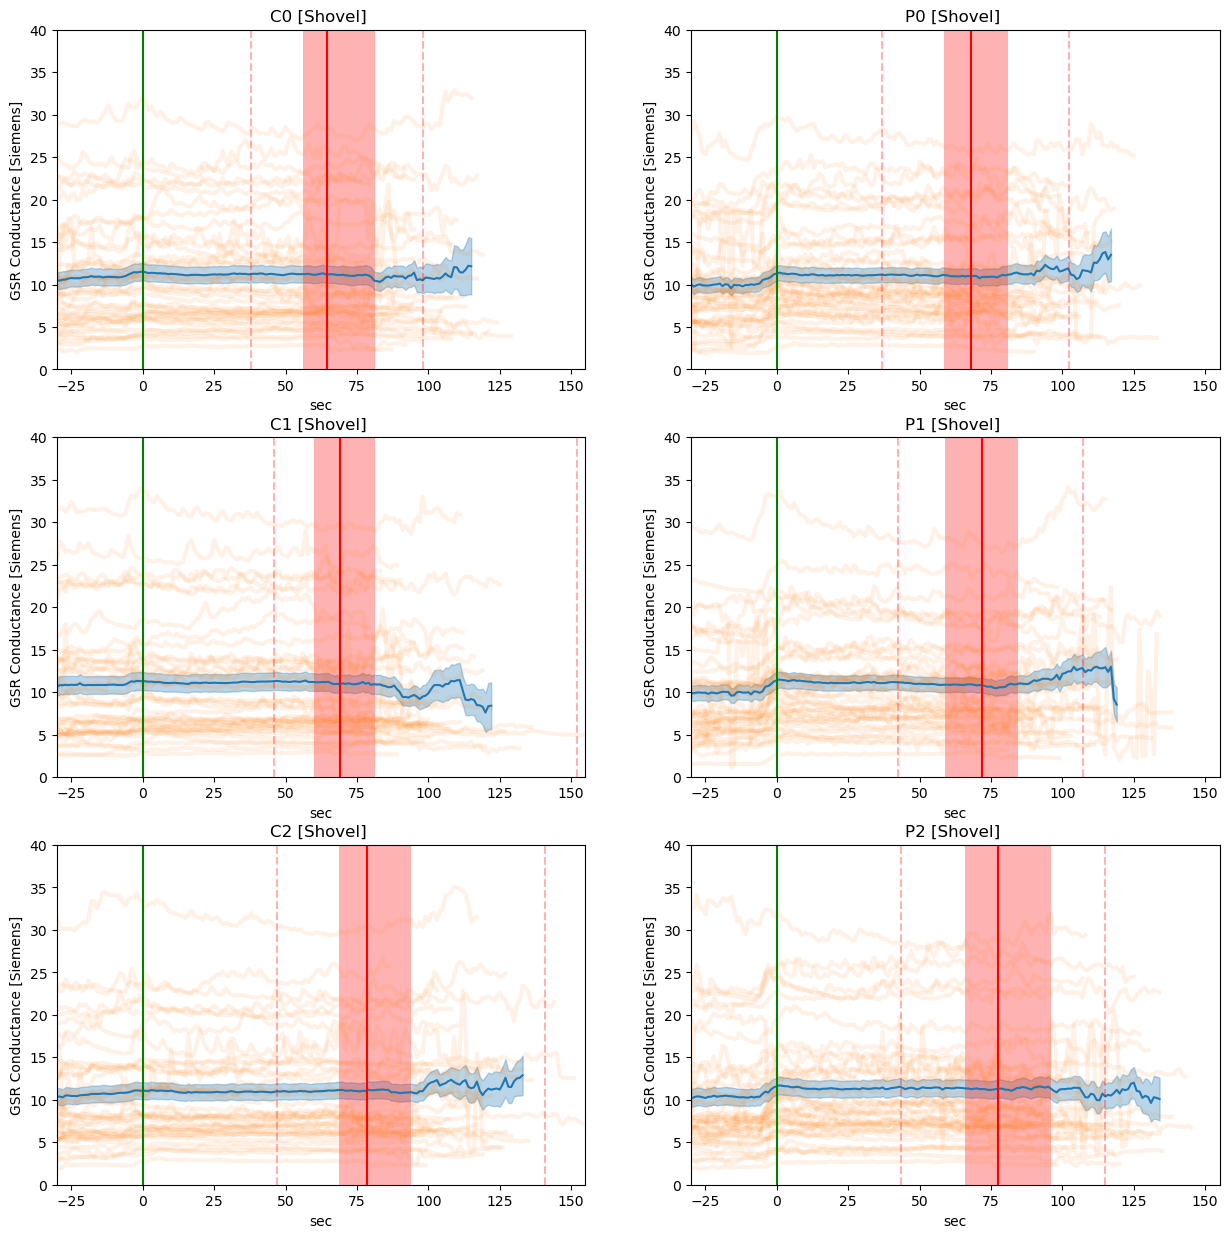

In [69]:
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
ylim = [0,40]
ylabel = 'GSR Conductance [Siemens]'

agg_curve(data, axs[0,0], shovel, c_0, gsr_con_key, ylim, ylabel)
agg_curve(data, axs[1,0], shovel, c_1, gsr_con_key, ylim, ylabel)
agg_curve(data, axs[2,0], shovel, c_2, gsr_con_key, ylim, ylabel)
agg_curve(data, axs[0,1], shovel, p_0, gsr_con_key, ylim, ylabel)
agg_curve(data, axs[1,1], shovel, p_1, gsr_con_key, ylim, ylabel)
agg_curve(data, axs[2,1], shovel, p_2, gsr_con_key, ylim, ylabel)

plt.show()

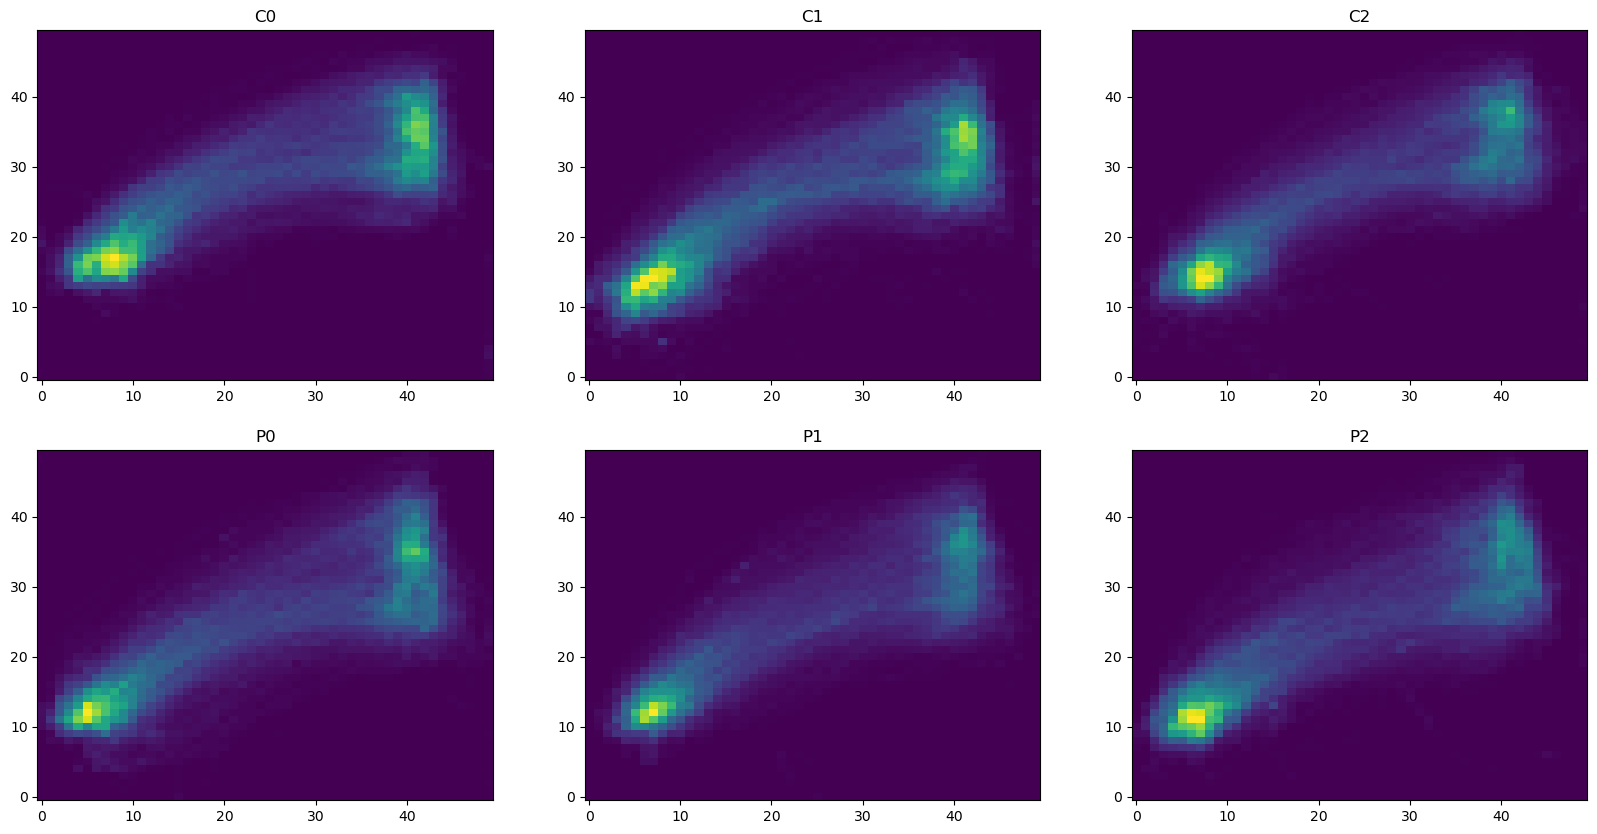

In [70]:
end_effector = 'ee'
primary_tracked = 'pt'
primary_visible = 'pv'
secondary_tracked = 'st'
secondary_visible = 'sv'
hmd = 'hmd'

tracking_pts = [end_effector, primary_tracked, primary_visible, secondary_tracked, secondary_visible, hmd]

def mirror_x(df, pt):
    key = pt + '_x'
    df[key] = df.apply(lambda x: -x[key] if x['primary_grab_hand'] == 'Left' else x[key], axis = 1)

def rectify_unity (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    for pt in tracking_pts:
        mirror_x(df, pt)

    return df

def top_heatmap(data, ax, e, c, pt):
    participants = list(map(lambda x: x[e][c], data))

    dfs = list(map(lambda x: rectify_unity(x), participants))
    all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

    max_x = 0.25
    min_x = -1.75

    lateral = np.clip(list(all_values[pt + "_x"]), min_x, max_x)
    forward = list(all_values[pt + "_z"])
    vertical = list(all_values[pt + "_y"])

    heatmap, xedges, yedges = np.histogram2d(lateral, forward, bins=50)

    ax.title.set_text(c)
    ax.imshow(heatmap.T, origin='lower', cmap='viridis', aspect='auto')


fig, axs = plt.subplots(2, 3, figsize=(20, 10))

shovel_tip = 'ee'
secondary_hand = 'st'
primary_hand = 'pt'

top_heatmap(data, axs[0,0], shovel, c_0, shovel_tip)
top_heatmap(data, axs[0,1], shovel, c_1, shovel_tip)
top_heatmap(data, axs[0,2], shovel, c_2, shovel_tip)
top_heatmap(data, axs[1,0], shovel, p_0, shovel_tip)
top_heatmap(data, axs[1,1], shovel, p_1, shovel_tip)
top_heatmap(data, axs[1,2], shovel, p_2, shovel_tip)

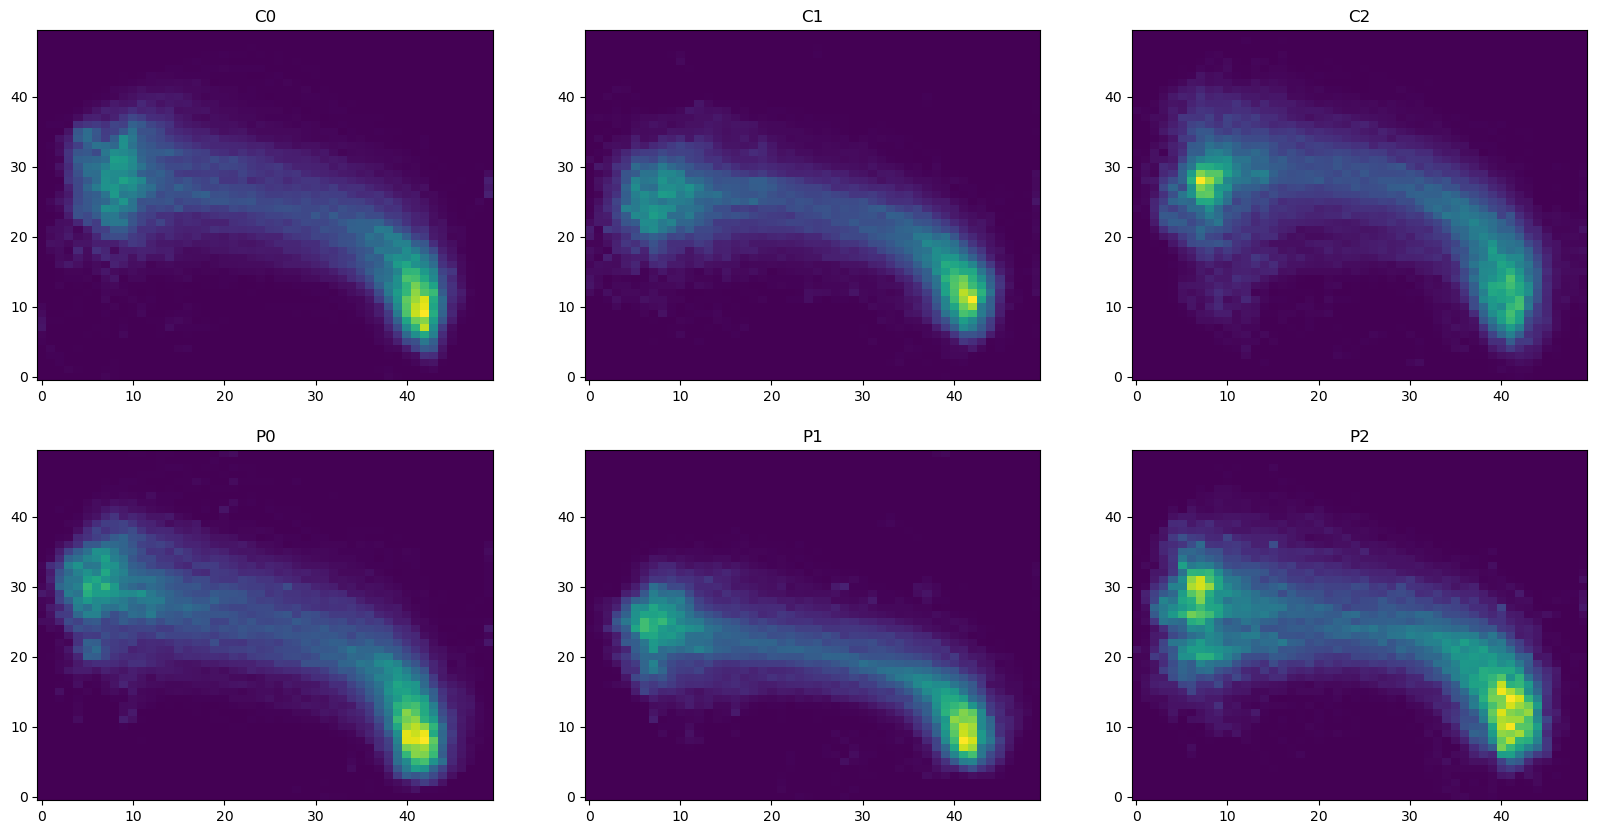

In [71]:
def front_heatmap(data, ax, e, c, pt):
    participants = list(map(lambda x: x[e][c], data))

    dfs = list(map(lambda x: rectify_unity(x), participants))
    all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

    max_x = 0.25
    min_x = -1.75

    lateral = np.clip(list(all_values[pt + "_x"]), min_x, max_x)
    forward = list(all_values[pt + "_z"])
    vertical = list(all_values[pt + "_y"])

    heatmap, xedges, yedges = np.histogram2d(lateral, vertical, bins=50)

    ax.title.set_text(c)
    ax.imshow(heatmap.T, origin='lower', cmap='viridis', aspect='auto')


fig, axs = plt.subplots(2, 3, figsize=(20, 10))

shovel_tip = 'ee'
secondary_hand = 'st'
primary_hand = 'pt'

front_heatmap(data, axs[0,0], shovel, c_0, shovel_tip)
front_heatmap(data, axs[0,1], shovel, c_1, shovel_tip)
front_heatmap(data, axs[0,2], shovel, c_2, shovel_tip)
front_heatmap(data, axs[1,0], shovel, p_0, shovel_tip)
front_heatmap(data, axs[1,1], shovel, p_1, shovel_tip)
front_heatmap(data, axs[1,2], shovel, p_2, shovel_tip)

In [72]:
# def scatter_3D(data, fig, index, e, c, pt):
#     participants = list(map(lambda x: x[e][c], data))

#     dfs = list(map(lambda x: rectify_unity(x), participants))
#     all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

#     max_x = 0.25
#     min_x = -1.75

#     lateral = list(all_values[pt + "_x"])
#     forward = list(all_values[pt + "_z"])
#     vertical = list(all_values[pt + "_y"])

#     # Create a figure and 3D axis
#     # fig = plt.figure(figsize=(8,6))
#     # ax = fig.add_subplot(111, projection='3d')
#     ax = fig.add_subplot(1, 2, index, projection='3d')

#     ax.set_zlim(0, 1.5)
#     ax.set_xlim(-2, 0.5)
#     ax.set_ylim(-0.5, 2)

#     # Create scatter plot
#     ax.scatter3D(lateral, forward, vertical, color='tab:blue', alpha=0.01, s=0.5)



#     # Labels
#     ax.set_xlabel('Lateral')
#     ax.set_ylabel('Forward')
#     ax.set_zlabel('Vertical')
#     ax.set_title(c)


# fig = plt.figure(figsize=plt.figaspect(0.25))

# shovel_tip = 'ee'
# secondary_hand = 'st'
# primary_hand = 'pt'

# scatter_3D(data, fig, 1, shovel, c_0, shovel_tip)
# scatter_3D(data, fig, 2, shovel, c_1, shovel_tip)
# scatter_3D(data, fig, 3, shovel, c_2, shovel_tip)
# scatter_3D(data, fig, 4, shovel, p_0, shovel_tip)
# scatter_3D(data, fig, 5, shovel, p_1, shovel_tip)
# scatter_3D(data, fig, 6, shovel, p_2, shovel_tip)

# plt.show()


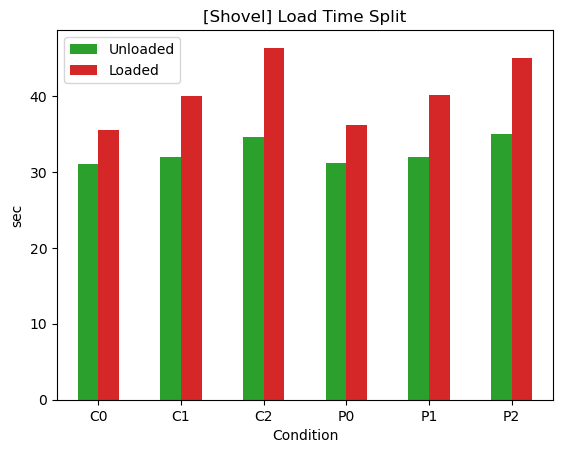

In [73]:
def single_load_time_split (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    loaded_time = 0
    unloaded_time = 0

    for i in range(20):
        single = df[(df["collision_or_load_count"] == i+1)]

        unloaded = single[(single["shovel_loaded_state"] == False)]
        unloaded_time += unloaded[unity_unix_key].max() - unloaded[unity_unix_key].min()

        loaded = single[(single["shovel_loaded_state"] == True)]
        loaded_time += loaded[unity_unix_key].max() - loaded[unity_unix_key].min()
    
    return [unloaded_time / 1_000, loaded_time / 1_000]

def agg_load_time_split(data, c):
    participants = list(map(lambda x: x[shovel][c], data))

    splits = list(map(lambda x: single_load_time_split(x), participants))
    
    unloaded_times = list(map(lambda x: x[0], splits))
    loaded_times = list(map(lambda x: x[1], splits))
    
    return [np.mean(unloaded_times), np.mean(loaded_times)]

condition_splits = list(map(lambda x: agg_load_time_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["Unloaded", "Loaded"], index = conditions)

df.plot(kind='bar', color=["tab:green", "tab:red"])

plt.title("[Shovel] Load Time Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

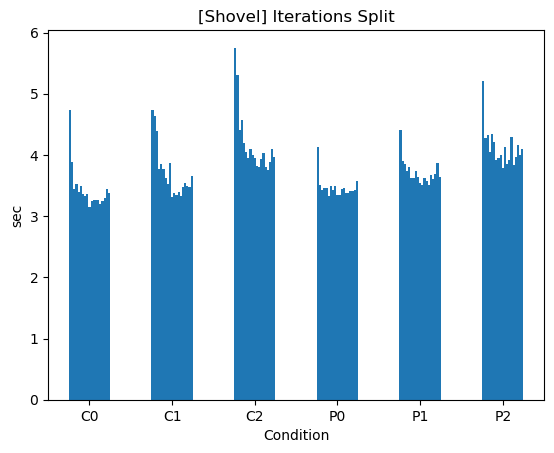

In [74]:
n_iterations = range(19)

def single_iteration_split (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    iteration_times = []

    for i in n_iterations:
        iteration = df[(df["collision_or_load_count"] == i+1)]
        time = (iteration[unity_unix_key].max() - iteration[unity_unix_key].min() ) / 1_000
        iteration_times.append(time)
    
    return iteration_times

def agg_iteration_split(data, c):
    participants = list(map(lambda x: x[shovel][c], data))

    participant_splits = list(map(lambda x: single_iteration_split(x), participants))
    n_participants = len(participants)

    splits = []

    for i in n_iterations:
        splits.append([])
        for j in range(n_participants):
            splits[i].append(participant_splits[j][i])

    split_means = list(map(lambda x: np.mean(x), splits))
    
    return split_means

condition_splits = list(map(lambda x: agg_iteration_split(data, x), conditions))

columns = list(map(lambda x: str(x+1), n_iterations))

df = pd.DataFrame(condition_splits, columns=columns, index = conditions)

df.plot(kind='bar', color = "tab:blue", legend=False)

plt.title("[Shovel] Iterations Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

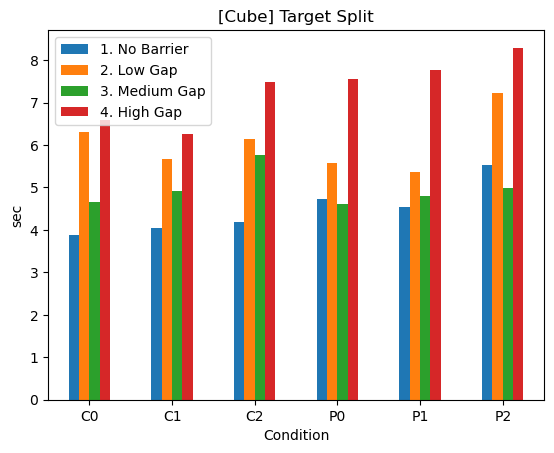

In [75]:
def single_target_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_time = first[unified_unix_key].max() - first[unified_unix_key].min()
    second_time = second[unified_unix_key].max() - second[unified_unix_key].min()
    third_time = third[unified_unix_key].max() - third[unified_unix_key].min()
    fourth_time = fourth[unified_unix_key].max() - fourth[unified_unix_key].min()

    return [first_time / 1_000, second_time / 1_000, third_time / 1_000, fourth_time / 1_000]

def agg_target_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_target_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.mean(first), np.mean(second), np.mean(third), np.mean(fourth)]

condition_splits = list(map(lambda x: agg_target_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Target Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

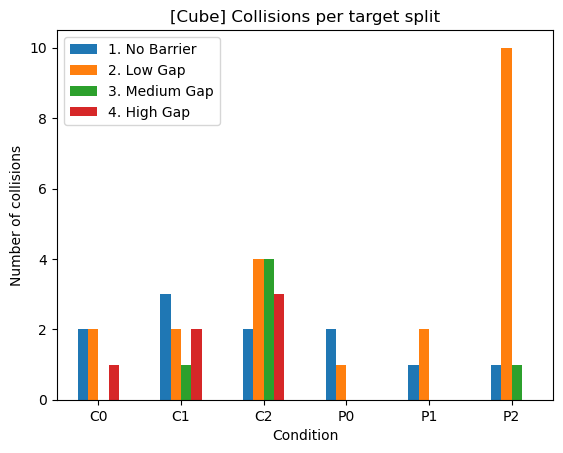

In [76]:
def single_collision_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_collisons =first["collision_or_load_count"].max() - first["collision_or_load_count"].min()
    second_collisons =second["collision_or_load_count"].max() - second["collision_or_load_count"].min()
    third_collisons =third["collision_or_load_count"].max() - third["collision_or_load_count"].min()
    fourth_collisons =fourth["collision_or_load_count"].max() - fourth["collision_or_load_count"].min()

    return [first_collisons, second_collisons, third_collisons, fourth_collisons]

def agg_collision_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_collision_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.sum(first), np.sum(second), np.sum(third), np.sum(fourth)]

condition_splits = list(map(lambda x: agg_collision_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Collisions per target split")
plt.xlabel("Condition")
plt.ylabel("Number of collisions")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

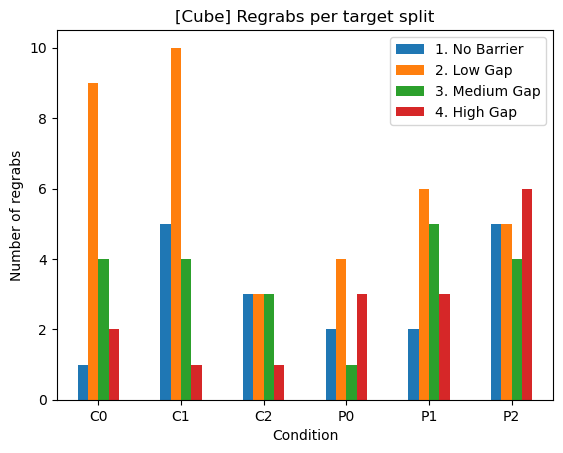

In [77]:
def single_grabcount_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_regrabs =first["grab_count"].max() - first["grab_count"].min()
    second_regrabs =second["grab_count"].max() - second["grab_count"].min()
    third_regrabs =third["grab_count"].max() - third["grab_count"].min()
    fourth_regrabs =fourth["grab_count"].max() - fourth["grab_count"].min()

    return [first_regrabs, second_regrabs, third_regrabs, fourth_regrabs]

def agg_grabcount_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_grabcount_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.sum(first), np.sum(second), np.sum(third), np.sum(fourth)]

condition_splits = list(map(lambda x: agg_grabcount_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Regrabs per target split")
plt.xlabel("Condition")
plt.ylabel("Number of regrabs")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

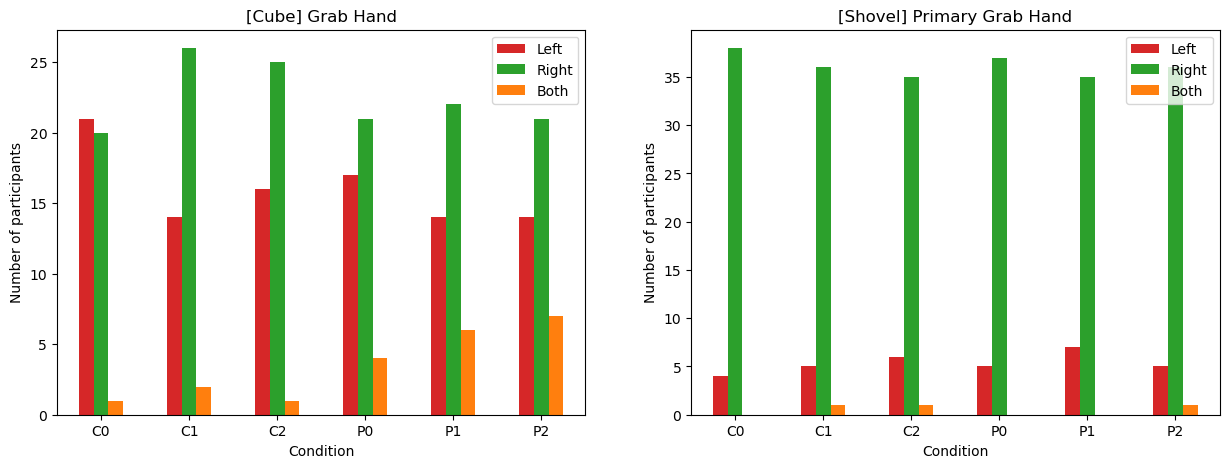

In [78]:
primary_left = "Left"
primary_right = "Right"
primary_both = "Both"
primary_none = "None"

primary_options = [primary_left, primary_right, primary_both]

def single_primary_hand(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    left = (df['primary_grab_hand'] == primary_left).any()
    right = (df['primary_grab_hand'] == primary_right).any()

    if left & right:
        return primary_both
    elif left:
        return primary_left
    elif right:
        return primary_right
    else:
        return primary_none

def agg_primary_hand(data, e, c):
    participants = list(map(lambda x: x[e][c], data))

    participant_hands = list(map(lambda x: single_primary_hand(x), participants))

    left = 0
    right = 0
    both = 0
    none = 0

    for i in range(len(participant_hands)):
        hands = participant_hands[i]

        if hands == primary_left:
            left += 1
        elif hands == primary_right:
            right += 1
        elif hands == primary_both:
            both += 1
        elif hands == primary_none:
            none += 1
    
    return [left, right, both]

cube_hands = list(map(lambda x: agg_primary_hand(data, cube, x), conditions))
cube_hands_df = pd.DataFrame(cube_hands, columns=primary_options, index = conditions)

shovel_hands = list(map(lambda x: agg_primary_hand(data, shovel, x), conditions))
shovel_hands_df = pd.DataFrame(shovel_hands, columns=primary_options, index = conditions)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cube_hands_df.plot(kind='bar', color=["tab:red", "tab:green", "tab:orange"], ax=axs[0])
axs[0].set_title('[Cube] Grab Hand')
axs[0].set_xlabel('Condition')
axs[0].set_ylabel('Number of participants')
axs[0].xaxis.set_tick_params(rotation=0)

shovel_hands_df.plot(kind='bar', color=["tab:red", "tab:green", "tab:orange"], ax=axs[1])
axs[1].set_title('[Shovel] Primary Grab Hand')
axs[1].set_xlabel('Condition')
axs[1].set_ylabel('Number of participants')
axs[1].xaxis.set_tick_params(rotation=0)

plt.show()

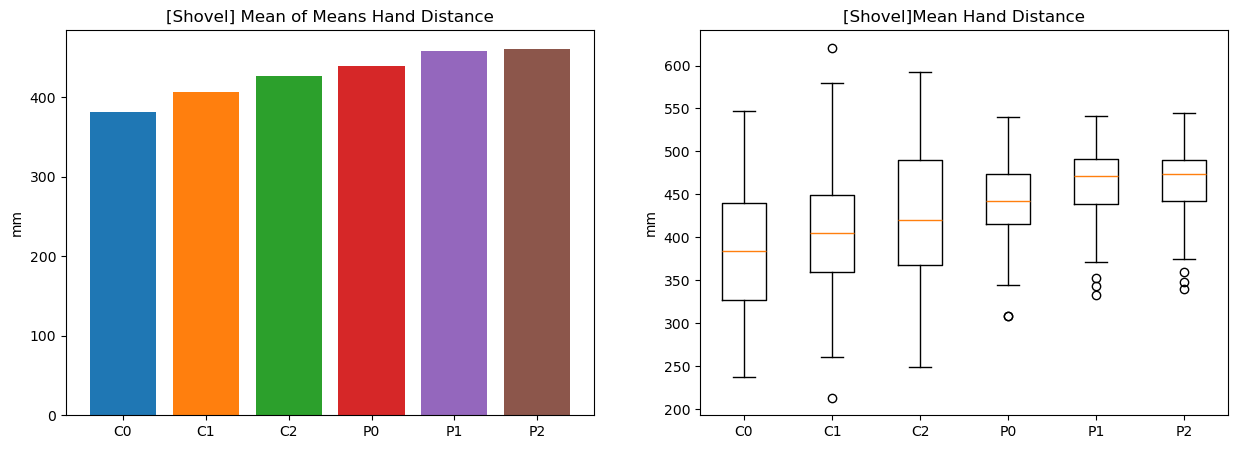

[Shovel] Mean Hand Distance


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),1.449157e+05,1.0,31.640352,5.030610e-08,✅
C(Scaling),4.786370e+04,2.0,5.225192,5.992469e-03,✅
C(Device):C(Scaling),6.456889e+03,2.0,0.704887,4.951599e-01,❌
Residual,1.126702e+06,246.0,NaN,NaN,❌


In [79]:
primary_tracked = "pt"
secondary_tracked = "st"
primary_visible = "pv"
secondary_visible = "sv"

def single_hand_distance(p, pt_1, pt_2):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    df["dist"] = df.apply(lambda x: distance.euclidean((x[pt_1 + "_x"], x[pt_1 + "_y"], x[pt_1 + "_z"]), (x[pt_2 + "_x"], x[pt_2 + "_y"], x[pt_2 + "_z"])), axis = 1)

    return df["dist"].mean() * 1_000

def agg_hand_distance(data, c):
    participants = list(map(lambda x: x[shovel][c], data))
    single_values = list(map(lambda x: single_hand_distance(x, primary_tracked, secondary_tracked), participants))
    return single_values

values = list(map(lambda x: agg_hand_distance(data, x), conditions))

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

labels = conditions

title = "Mean Hand Distance"
means = list(map(lambda x: np.mean(x), values))
axs[0].bar(labels, means, color=colors)
axs[0].set_title('[Shovel] Mean of Means Hand Distance')
axs[0].set_ylabel('mm')

axs[1].boxplot(values, tick_labels=labels)
axs[1].set_title('[Shovel]' + title)
axs[1].set_ylabel('mm')

plt.show()

two_way_anova(values, shovel, title)

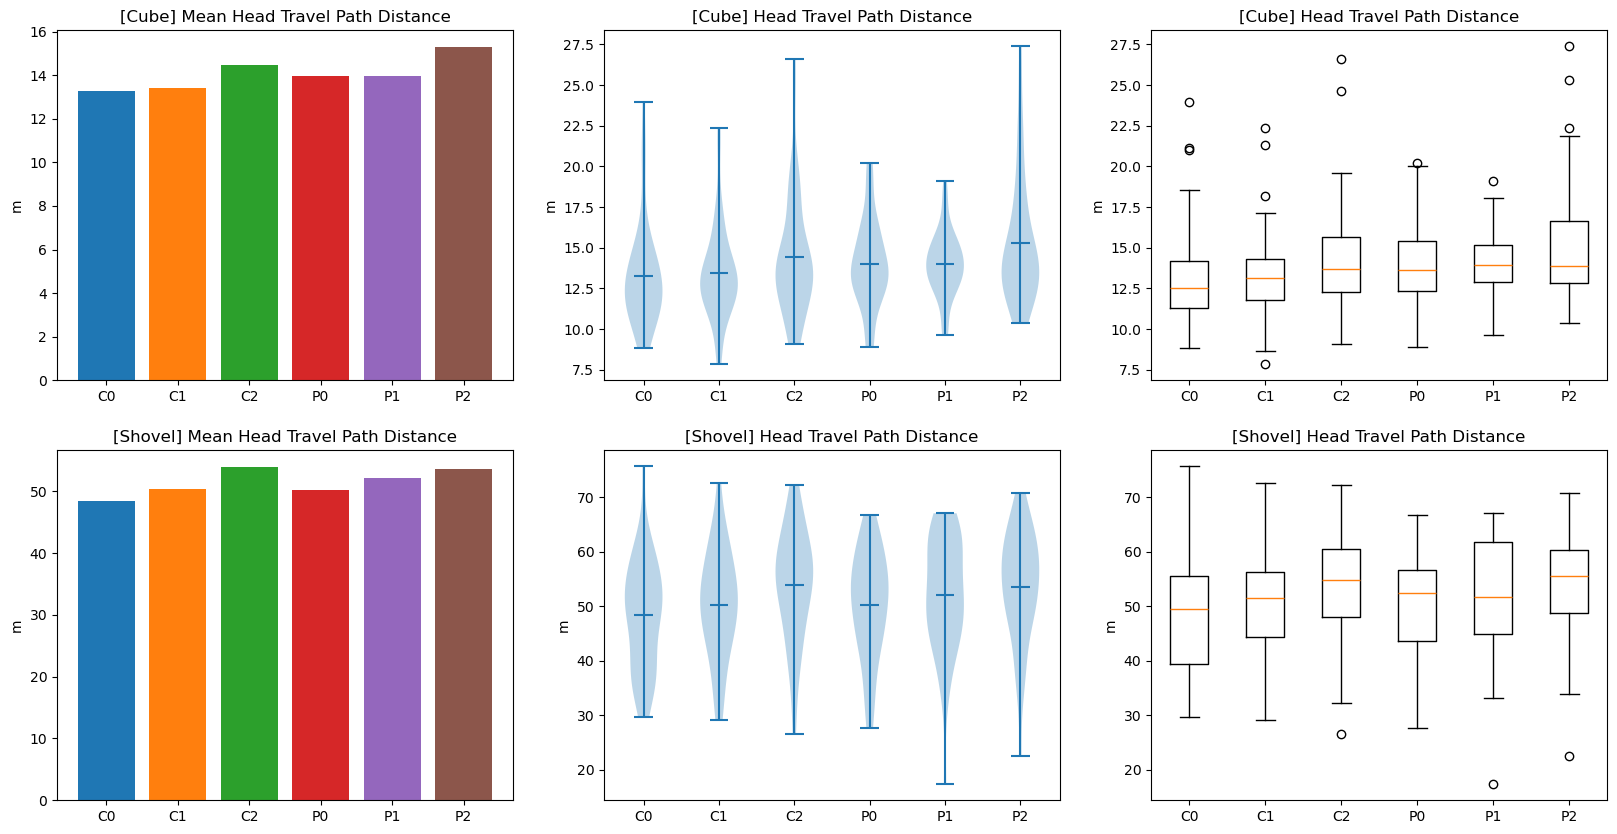

[Cube] Head Travel Path Distance


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),30.792265,1.0,3.160769,0.076663,❌
C(Scaling),81.780435,2.0,4.197305,0.016127,✅
C(Device):C(Scaling),0.833778,2.0,0.042793,0.958117,❌
Residual,2396.536126,246.0,NaN,NaN,❌


[Shovel] Head Travel Path Distance


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),75.152495,1.0,0.727321,0.394582,❌
C(Scaling),827.052047,2.0,4.002080,0.019480,✅
C(Device):C(Scaling),65.220379,2.0,0.315599,0.729646,❌
Residual,25418.633125,246.0,NaN,NaN,❌


In [80]:
hmd = "hmd"

def single_pos_delta(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    df[pt + "_x_delta"] = df[pt + "_x"].diff()
    df[pt + "_y_delta"] = df[pt + "_y"].diff()
    df[pt + "_z_delta"] = df[pt + "_z"].diff()

    df = df.dropna(subset = [pt + "_x_delta", pt + "_y_delta", pt + "_z_delta"])

    df["delta_dist"] = df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_y_delta"], x[pt + "_z_delta"]), (0,0,0)), axis = 1)

    return df["delta_dist"].sum()

def agg_pos_delta(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: single_pos_delta(x, hmd), participants))
    return single_values

cube_values = list(map(lambda x: agg_pos_delta(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_pos_delta(data, shovel, x), conditions))

title = 'Head Travel Path Distance'
ylabel = 'm'
plot_experiments(cube_values, shovel_values, title, ylabel)
two_way_anova(cube_values, cube, title)
two_way_anova(shovel_values, shovel, title)